<a href="https://colab.research.google.com/github/pl-gonzalez/fase5-cap1-farmtech/blob/main/PabloGonzalez_RM567944_fase5_cap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 5 - Capitulo 1 - Atividade FarmTech
*  Analisar uma base de dados (crop_yield.csv) com informações de condições de solo e temperatura, relacionadas com o tipo de produto agrícola dessa fazenda. O modelo deve prever o rendimento de safra e explorar a tendência de produtividade

## 1. Descrição dos dados



* Cultura apresenta 4 tipos de cultura diferentes, e serão levados em consideração para a analise das variáveis climáticas e resultados como rendimento.
  * Cacau, Fruta de Dendê, Arroz e Borracha
  * Cada tpo de cultura tem 39 ocorrencias, apresentando uma distribuição igual

* A base de dados contem 156 dados e 6 colunas, sendo elas:

  * **Cultura**: o nome da safra para a qual o rendimento está sendo medido.

  * **Precipitação (mm dia 1)**: a quantidade de chuva em milímetros por dia.

  * **Umidade específica a 2 metros (g/kg)**: a quantidade de vapor de água no ar por quilograma de ar seco a uma altura de 2 metros acima do solo.

  * **Umidade relativa a 2 metros (%)**: a quantidade de vapor de água no ar como uma  porcentagem da quantidade máxima de vapor de água que pode ser mantida a uma determinada temperatura e pressão.

  * **Temperatura a 2 metros (ºC)**: a temperatura em graus Celsius a uma altura de 2 metros acima do solo.

  * **Rendimento**: a quantidade de rendimento em toneladas por hectare.


In [335]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [336]:
df = pd.read_csv("crop_yield.csv")
df.columns = ['Cultura','Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)', 'Rendimento']

df.info()
# df.describe()
df

# df['Cultura_Descricao'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cultura                               156 non-null    object 
 1   Precipitação (mm dia 1)               156 non-null    float64
 2   Umidade específica a 2 metros (g/kg)  156 non-null    float64
 3   Umidade relativa a 2 metros (%)       156 non-null    float64
 4   Temperatura a 2 metros (ºC)           156 non-null    float64
 5   Rendimento                            156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
...,...,...,...,...,...,...
151,"Rubber, natural",2308.51,18.27,83.65,26.47,6721
152,"Rubber, natural",2410.13,18.58,83.45,26.81,6248
153,"Rubber, natural",2967.41,18.67,85.48,26.46,6842
154,"Rubber, natural",2333.46,18.50,84.85,26.43,5571


In [337]:
# Copia dataframe original, mantendo o original como é
novo_df = df


traducoes = {
    'cocoa, beans': 'cacau, grãos',
    'rubber, natural': 'borracha, natural',
    'oil palm fruit': 'fruta de dendê',
    'rice, paddy': 'arroz, arrozal',
}

novo_df['Cultura'] = novo_df['Cultura'].str.lower().replace(traducoes).str.title()
novo_df = novo_df[['Cultura', 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)', 'Rendimento']]

novo_df

,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,"Cacau, Grãos",2248.92,17.72,83.40,26.01,11560
1,"Cacau, Grãos",1938.42,17.54,82.11,26.11,11253
2,"Cacau, Grãos",2301.54,17.81,82.79,26.24,9456
3,"Cacau, Grãos",2592.35,17.61,85.07,25.56,9321
4,"Cacau, Grãos",2344.72,17.61,84.12,25.76,8800
...,...,...,...,...,...,...
151,"Borracha, Natural",2308.51,18.27,83.65,26.47,6721
152,"Borracha, Natural",2410.13,18.58,83.45,26.81,6248
153,"Borracha, Natural",2967.41,18.67,85.48,26.46,6842
154,"Borracha, Natural",2333.46,18.50,84.85,26.43,5571


In [338]:
novo_df['Cultura'].unique()

array(['Cacau, Grãos', 'Fruta De Dendê', 'Arroz, Arrozal',
       'Borracha, Natural'], dtype=object)

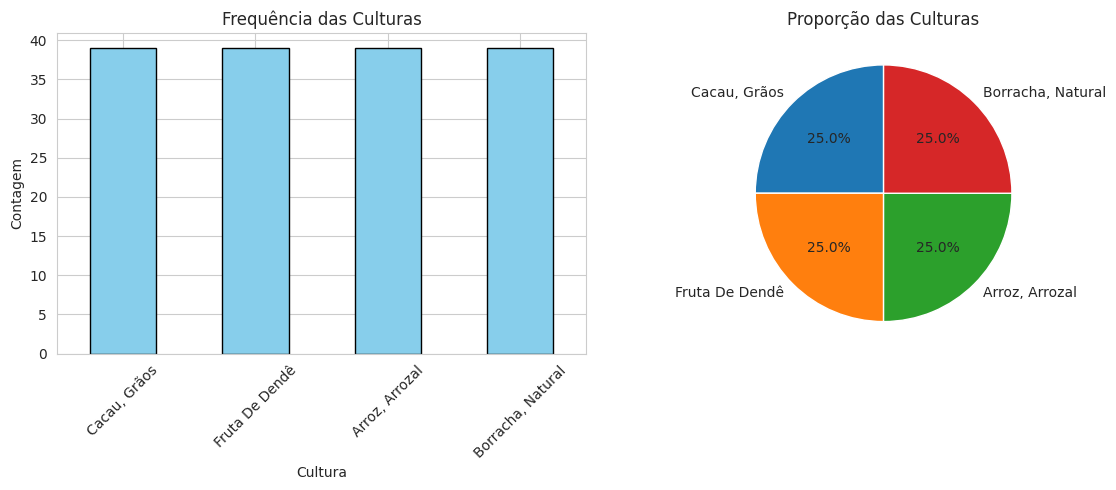

In [339]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
novo_df['Cultura'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Frequência das Culturas')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)

# Pizza
novo_df['Cultura'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção das Culturas')
axes[1].set_ylabel('')

# print(novo_df['Cultura'].value_counts())
plt.tight_layout()
plt.show()

### 1.1 Resumo estatístico

In [340]:
# # ✅ Médias de todas as variáveis por cultura
print("📊 MÉDIAS POR CULTURA:")
print(novo_df.groupby('Cultura').mean())

# # ✅ Estatísticas completas
# print("\n📊 ESTATÍSTICAS DETALHADAS:")
# print(novo_df.groupby('Cultura').describe())

# # ✅ Apenas uma variável específica
# print("\n📊 YIELD POR CULTURA:")
# print(novo_df.groupby('Cultura')['Rendimento'].agg(['mean', 'std', 'min', 'max']).round(0))

📊 MÉDIAS POR CULTURA:
                   Precipitação (mm dia 1)  \
Cultura                                      
Arroz, Arrozal                 2486.498974   
Borracha, Natural              2486.498974   
Cacau, Grãos                   2486.498974   
Fruta De Dendê                 2486.498974   

                   Umidade específica a 2 metros (g/kg)  \
Cultura                                                   
Arroz, Arrozal                                18.203077   
Borracha, Natural                             18.203077   
Cacau, Grãos                                  18.203077   
Fruta De Dendê                                18.203077   

                   Umidade relativa a 2 metros (%)  \
Cultura                                              
Arroz, Arrozal                           84.737692   
Borracha, Natural                        84.737692   
Cacau, Grãos                             84.737692   
Fruta De Dendê                           84.737692   

                   Te

* A média dos valores das variaveis climáticas apresentam o mesmo valor, indicando que todas as culturas estão sujeitas as mesmas condições de solo.
* Podemos notar pela média que a cultura com maior rendimento é a Fruta de Dende
* Temperatura média: 26,18°C
* Preciptação média: 2486,5 mm
* Umidade especifica a 2 metros: 18,20 g/kg
* Umidade relativa a 2 metros: 84,73 %
* Rendimento médio
  * Arroz: 32099,67
  * Borracha: 7824,9
  * Cacau: 8883,13
  * Fruta de Dendê: 175804,69

## 2. Limpeza e Organização dos Dados

* Não há dados ausentes ou duplicados
  * Mesmo que o nome da Cultura possa ter varias repetições, as combinações de outros valores do clima com Rendimento, resultam em dados únicos.



#### 2.1 Valores nulos

In [341]:
novo_df.groupby('Cultura').apply(lambda x: x.isna().sum())


,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
Cultura,,,,,,
"Arroz, Arrozal",0,0,0,0,0,0
"Borracha, Natural",0,0,0,0,0,0
"Cacau, Grãos",0,0,0,0,0,0
Fruta De Dendê,0,0,0,0,0,0


In [342]:
novo_df.isna().sum()

,0
Cultura,0
Precipitação (mm dia 1),0
Umidade específica a 2 metros (g/kg),0
Umidade relativa a 2 metros (%),0
Temperatura a 2 metros (ºC),0
Rendimento,0


#### 2.2 Valores Duplicados

In [343]:
novo_df.groupby('Cultura').apply(lambda x: x.duplicated().sum())

,0
Cultura,
"Arroz, Arrozal",0
"Borracha, Natural",0
"Cacau, Grãos",0
Fruta De Dendê,0


### 2.2 Limpeza de valores da coluna Cultura
* Os valores de Cultura foram separados para melhor compreensão do dado da cultura
  * Os valores foram separados por vírgula, em Cultura e Descrição
* A coluna Descrição foi excluida por conter valores nulos e não ser relevante para predição do modelo, visto que "natural" é abrangente demais


In [344]:
# Separar a coluna única em duas
novo_df[['Cultura', 'Descrição']] = novo_df['Cultura'].str.split(',', expand=True)

# Limpar espaços extras
novo_df['Cultura'] = novo_df['Cultura'].str.strip()

novo_df = novo_df.drop(columns=['Descrição'])

novo_df




,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,Cacau,2248.92,17.72,83.40,26.01,11560
1,Cacau,1938.42,17.54,82.11,26.11,11253
2,Cacau,2301.54,17.81,82.79,26.24,9456
3,Cacau,2592.35,17.61,85.07,25.56,9321
4,Cacau,2344.72,17.61,84.12,25.76,8800
...,...,...,...,...,...,...
151,Borracha,2308.51,18.27,83.65,26.47,6721
152,Borracha,2410.13,18.58,83.45,26.81,6248
153,Borracha,2967.41,18.67,85.48,26.46,6842
154,Borracha,2333.46,18.50,84.85,26.43,5571


## Engenharia de Features


In [345]:
novo_df.head()

,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,Cacau,2248.92,17.72,83.40,26.01,11560
1,Cacau,1938.42,17.54,82.11,26.11,11253
2,Cacau,2301.54,17.81,82.79,26.24,9456
3,Cacau,2592.35,17.61,85.07,25.56,9321
4,Cacau,2344.72,17.61,84.12,25.76,8800


## 4. Analise Univariada



#### 4.1 Preciptação


                    Média  Mediana  Desvio   Mínimo   Máximo
Cultura                                                     
Arroz, Arrozal     2486.5  2424.55   292.3  1934.62  3085.79
Borracha, Natural  2486.5  2424.55   292.3  1934.62  3085.79
Cacau, Grãos       2486.5  2424.55   292.3  1934.62  3085.79
Fruta De Dendê     2486.5  2424.55   292.3  1934.62  3085.79


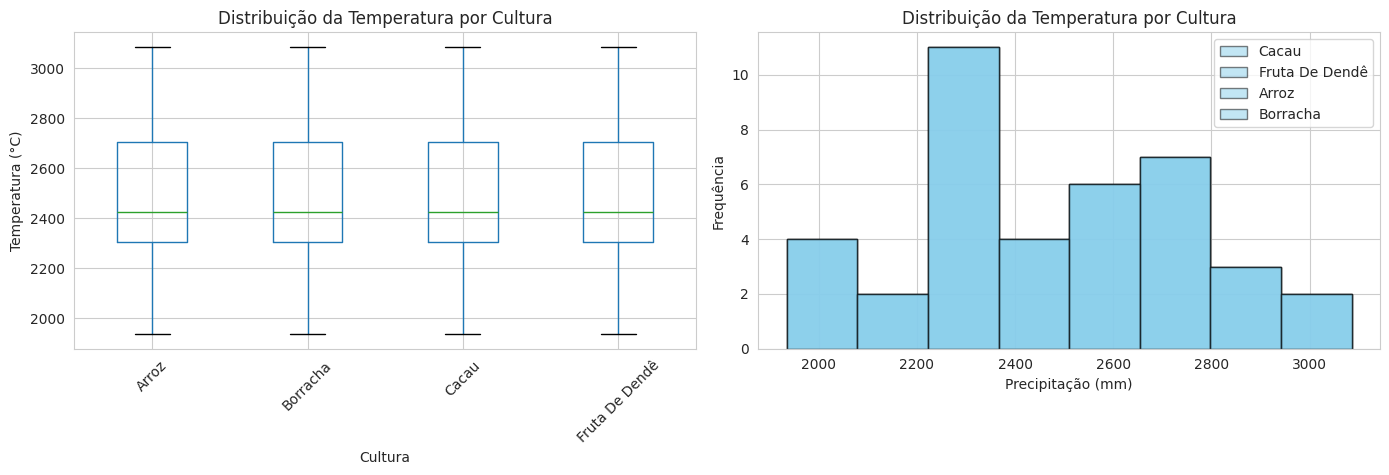

In [346]:
# Análise da Precipitação
variavel = 'Precipitação (mm dia 1)'


# Estatísticas de temperatura
temp_stats = df.groupby('Cultura')[variavel].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')
]).round(2)

print(temp_stats)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Boxplot
novo_df.boxplot(column=variavel, by='Cultura', ax=axes[0])
axes[0].set_title('Distribuição da Temperatura por Cultura')
axes[0].set_ylabel('Temperatura (°C)')

axes[0].tick_params(axis='x', rotation=45)
# Histogramas sobrepostos
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variavel]
    axes[1].hist(subset, bins=8, alpha=0.5, label=cultura,
                 color='skyblue', edgecolor='black')
axes[1].set_title('Distribuição da Temperatura por Cultura')
axes[1].set_xlabel('Precipitação (mm)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

# novo_df[variavel].value_counts()


#### 4.2 Umidade específica a 2 metros (g/kg)



                   Média  Mediana  Desvio  Mínimo  Máximo  CV%
Cultura                                                       
Arroz, Arrozal      18.0     18.0     0.0    18.0    19.0  2.0
Borracha, Natural   18.0     18.0     0.0    18.0    19.0  2.0
Cacau, Grãos        18.0     18.0     0.0    18.0    19.0  2.0
Fruta De Dendê      18.0     18.0     0.0    18.0    19.0  2.0


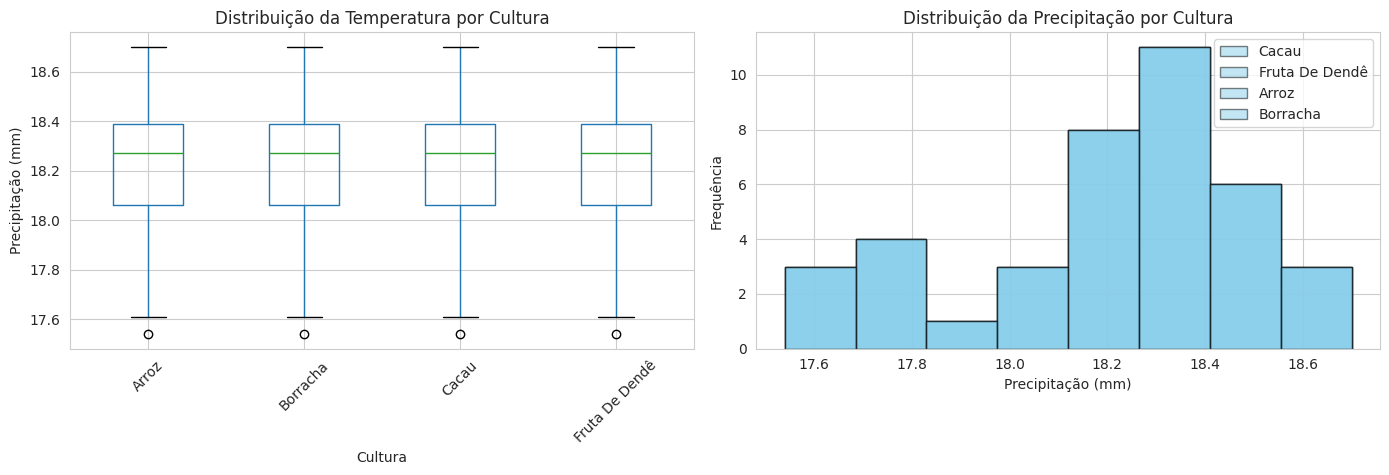

In [347]:
# Análise da Umidade específica a 2 metros
variavel = 'Umidade específica a 2 metros (g/kg)'



# Estatísticas de temperatura
temp_stats = df.groupby('Cultura')[variavel].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('CV%', lambda x: (x.std() / x.mean() * 100).round(1))
]).round(0)


print(temp_stats)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Boxplot
novo_df.boxplot(column=variavel, by='Cultura', ax=axes[0])
axes[0].set_title('Distribuição da Temperatura por Cultura')
axes[0].set_ylabel('Precipitação (mm)')

axes[0].tick_params(axis='x', rotation=45)
# Histogramas sobrepostos
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variavel]
    axes[1].hist(subset, bins=8, alpha=0.5, label=cultura,
                 color='skyblue', edgecolor='black')
axes[1].set_title('Distribuição da Precipitação por Cultura')
axes[1].set_xlabel('Precipitação (mm)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

# novo_df[variavel].value_counts()


* As médias proximas indicam condições atmosféricas estáveis


#### 4.3 Umidade relativa a 2 metros (%)



                   Média  Mediana  Desvio  Mínimo  Máximo
Cultura                                                  
Arroz, Arrozal     84.74    84.85    1.01   82.11    86.1
Borracha, Natural  84.74    84.85    1.01   82.11    86.1
Cacau, Grãos       84.74    84.85    1.01   82.11    86.1
Fruta De Dendê     84.74    84.85    1.01   82.11    86.1


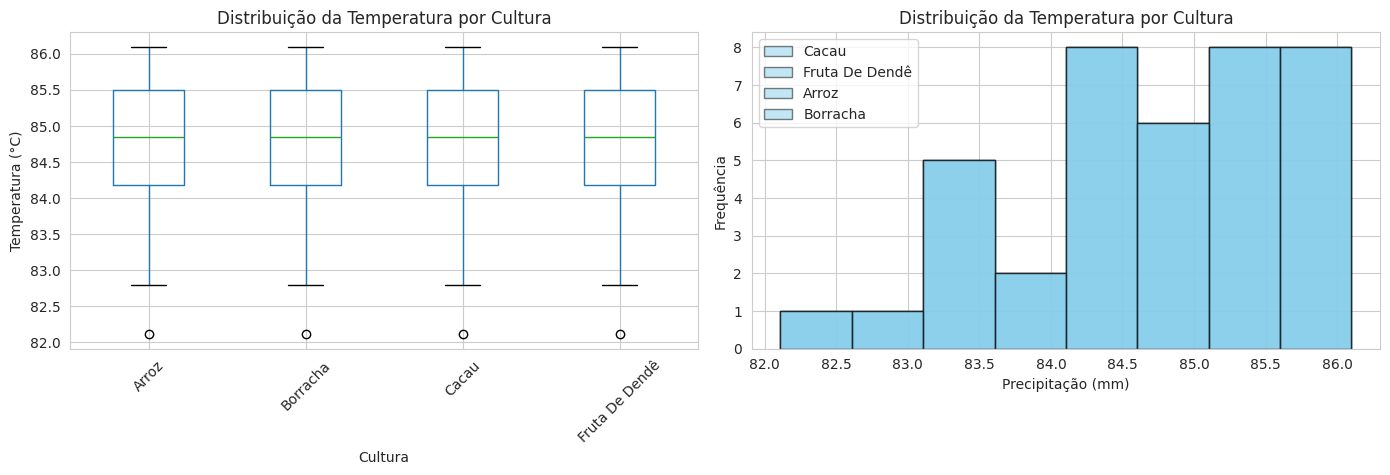

In [348]:
# Análise da Umidade relativa a 2 metros (%)
variavel = 'Umidade relativa a 2 metros (%)'



# Estatísticas de temperatura
temp_stats = df.groupby('Cultura')[variavel].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),

]).round(2)

print(temp_stats)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Boxplot
novo_df.boxplot(column=variavel, by='Cultura', ax=axes[0])
axes[0].set_title('Distribuição da Temperatura por Cultura')
axes[0].set_ylabel('Temperatura (°C)')

axes[0].tick_params(axis='x', rotation=45)
# Histogramas sobrepostos
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variavel]
    axes[1].hist(subset, bins=8, alpha=0.5, label=cultura,
                 color='skyblue', edgecolor='black')
axes[1].set_title('Distribuição da Temperatura por Cultura')
axes[1].set_xlabel('Precipitação (mm)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

# novo_df[variavel].value_counts()


* Variação < 2%, indicando um ambiente homogêneo.


#### 4.4 Temperatura a 2 metros do chão




🌡️ ANÁLISE DA TEMPERATURA POR CULTURA

📊 ESTATÍSTICAS DA TEMPERATURA POR CULTURA:
                   Média  Mediana  Desvio  Mínimo  Máximo
Cultura                                                  
Arroz, Arrozal     26.18    26.13    0.26   25.56   26.81
Borracha, Natural  26.18    26.13    0.26   25.56   26.81
Cacau, Grãos       26.18    26.13    0.26   25.56   26.81
Fruta De Dendê     26.18    26.13    0.26   25.56   26.81


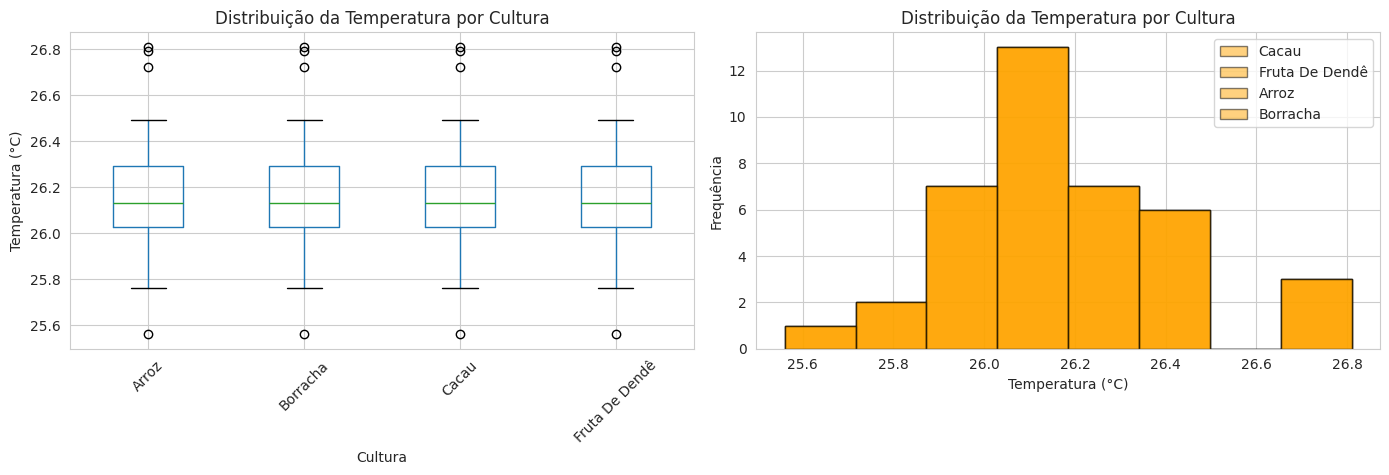

In [349]:
# Análise da Temperatura
variavel = 'Temperatura a 2 metros (ºC)'


print("\n" + "="*70)
print("🌡️ ANÁLISE DA TEMPERATURA POR CULTURA")
print("="*70)

# Estatísticas de temperatura
temp_stats = df.groupby('Cultura')[variavel].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')
]).round(2)

print("\n📊 ESTATÍSTICAS DA TEMPERATURA POR CULTURA:")
print(temp_stats)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
novo_df.boxplot(column=variavel, by='Cultura', ax=axes[0])
axes[0].set_title('Distribuição da Temperatura por Cultura')
axes[0].set_ylabel('Temperatura (°C)')

axes[0].tick_params(axis='x', rotation=45)
# Histogramas sobrepostos
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variavel]
    axes[1].hist(subset, bins=8, alpha=0.5, label=cultura,
                 color='orange', edgecolor='black')
axes[1].set_title('Distribuição da Temperatura por Cultura')
axes[1].set_xlabel('Temperatura (°C)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

# novo_df[variavel].value_counts()


#### 4.5 Rendimento



📊 ESTATÍSTICAS DO REDIMENTO POR CULTURA:
                      Média   Mediana   Desvio  Mínimo  Máximo  Amplitude  \
Cultura                                                                     
Arroz, Arrozal      32100.0   31101.0   4790.0   24686   42550      17864   
Borracha, Natural    7825.0    7817.0   1600.0    5249   10285       5036   
Cacau, Grãos         8883.0    8848.0   1745.0    5765   13056       7291   
Fruta De Dendê     175805.0  175629.0  14920.0  142425  203399      60974   

                    CV%  
Cultura                  
Arroz, Arrozal     15.0  
Borracha, Natural  20.0  
Cacau, Grãos       20.0  
Fruta De Dendê      8.0  


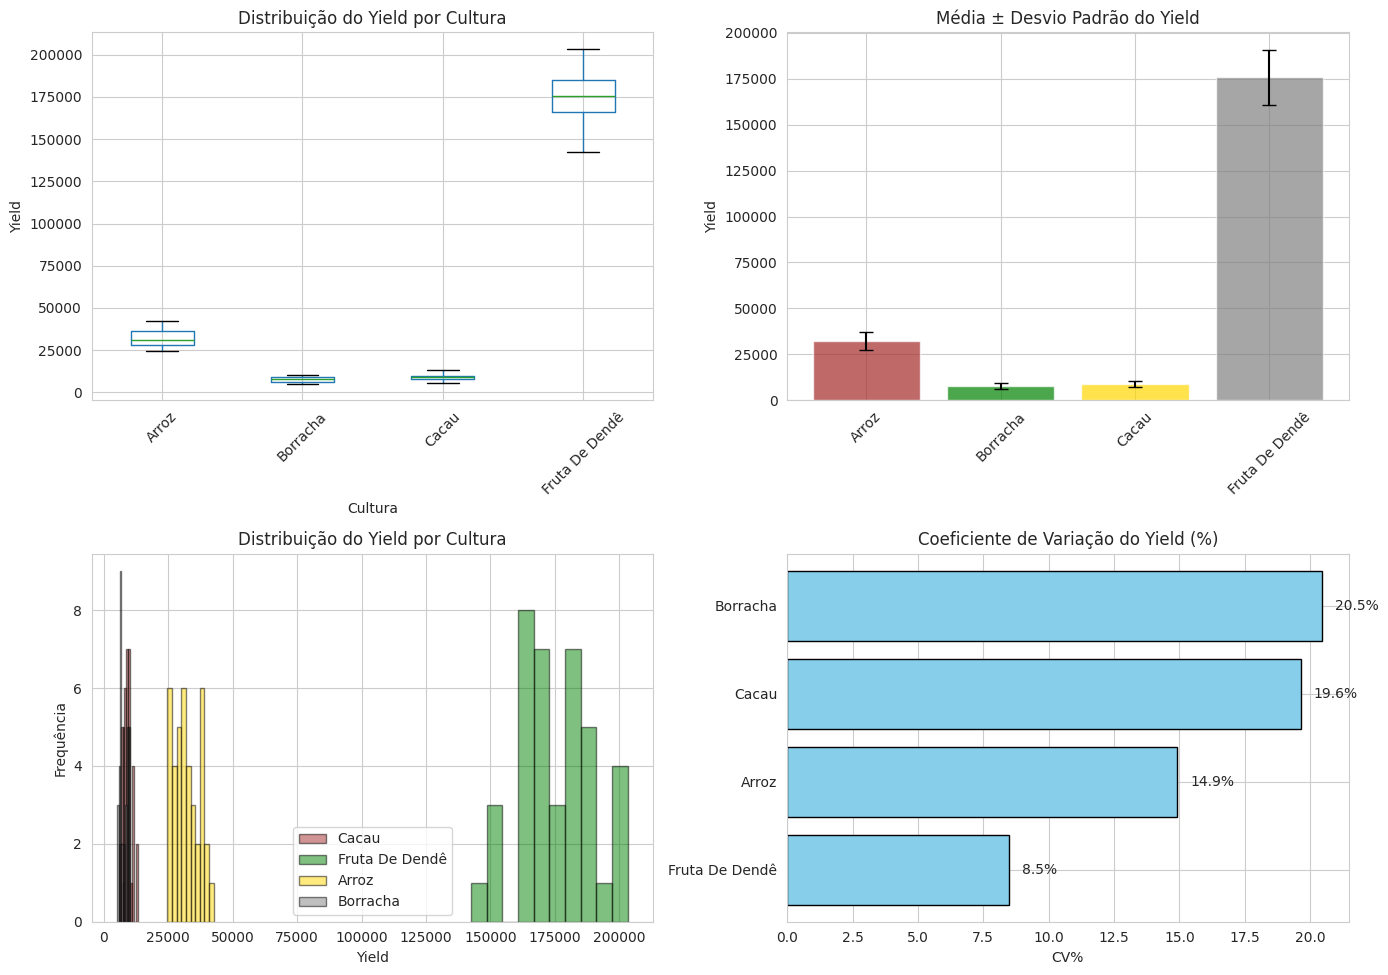

In [350]:
# Tabela comparativa de Yield
yield_stats = df.groupby('Cultura')['Rendimento'].agg([
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Amplitude', lambda x: x.max() - x.min()),
    ('CV%', lambda x: (x.std() / x.mean() * 100).round(1))
]).round(0)

print("\n📊 ESTATÍSTICAS DO REDIMENTO POR CULTURA:")
print(yield_stats)

# Gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot
novo_df.boxplot(column='Rendimento', by='Cultura', ax=axes[0,0])
axes[0,0].set_title('Distribuição do Yield por Cultura')
axes[0,0].set_ylabel('Yield')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Médias com barras de erro
medias = novo_df.groupby('Cultura')['Rendimento'].mean()
desvios = novo_df.groupby('Cultura')['Rendimento'].std()
axes[0,1].bar(medias.index, medias.values, yerr=desvios.values,
              capsize=5, color=['brown', 'green', 'gold', 'gray'], alpha=0.7)
axes[0,1].set_title('Média ± Desvio Padrão do Yield')
axes[0,1].set_ylabel('Yield')
axes[0,1].tick_params(axis='x', rotation=45)

# # 3. Histogramas sobrepostos
cores = {'Cacau': 'brown', 'Fruta De Dendê': 'green',
         'Arroz': 'gold', 'Borracha': 'gray'}

for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura]['Rendimento']
    axes[1,0].hist(subset, bins=10, alpha=0.5, label=cultura,
                   color=cores[cultura], edgecolor='black')
axes[1,0].set_title('Distribuição do Yield por Cultura')
axes[1,0].set_xlabel('Yield')
axes[1,0].set_ylabel('Frequência')
axes[1,0].legend()

# # 4. Coeficiente de variação
cv = novo_df.groupby('Cultura')['Rendimento'].apply(lambda x: (x.std() / x.mean() * 100)).sort_values()
axes[1,1].barh(cv.index, cv.values, color='skyblue', edgecolor='black')
axes[1,1].set_title('Coeficiente de Variação do Yield (%)')
axes[1,1].set_xlabel('CV%')
for i, v in enumerate(cv.values):
    axes[1,1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.suptitle('')  # Remove título automático
plt.tight_layout()
plt.show()

### 4.6 Observações da Análise Univariada


### a. **Rendimento Médio por Cultura**
| Cultura | Média ± Desvio | Coeficiente de Variação (CV) |
|---------|----------------|-------------------------------|
| Arroz   | 32.100 ± 4.790 | 14,9% |
| Borracha| 7.825 ± 1.600 | 20,5% |
| Cacau   | 8.883 ± 1.745 | 19,6% |
| Fruta de Dendê | 175.805 ± 14.920 | 8,5% |

### b. **Cultura com Maior Rendimento**
- **Fruta de Dendê:** 175.805

### c. **Cultura com Menor Rendimento**
- **Borracha:** 7.825

### d. **Cultura mais Estável (menor variabilidade)**
- **Fruta de Dendê:** CV = 8,5%

### e. **Cultura mais Variável (maior variabilidade)**
- **Borracha:** CV = 20,5%

### f. **Condições Climáticas Médias por Cultura**
As médias das variáveis climáticas são praticamente idênticas entre as culturas:

| Cultura | Temperatura (°C) | Precipitação (mm/dia) | Umidade Específica (g/kg) | Umidade Relativa (%) |
|---------|------------------|------------------------|----------------------------|----------------------|
| Arroz   | 26,18 | 2.486 | 18,2 | 84,7 |
| Borracha| 26,18 | 2.486 | 18,2 | 84,7 |
| Cacau   | 26,18 | 2.486 | 18,2 | 84,7 |
| Fruta de Dendê | 26,18 | 2.486 | 18,2 | 84,7 |

### g. **Amplitude Climática Geral (entre todas as observações)**
- **Temperatura:** 25,56°C – 26,81°C
- **Precipitação:** 1.935 – 3.086 mm/dia
- **Umidade específica:** 17,54 – 18,70 g/kg
- **Umidade relativa:** 82,1 – 86,1%

### h. **Observação Importante**
As médias das variáveis climáticas são muito próximas entre as culturas, indicando que todas foram expostas a condições ambientais semelhantes.  
As diferenças de rendimento, portanto, **não podem ser atribuídas ao clima**, mas sim a fatores intrínsecos de cada cultura (genética, manejo, solo, etc.).

In [351]:
print("="*70)
print("PRINCIPAIS DESCOBERTAS - ANÁLISE UNIVARIADA")
print("="*70)

# 1. RENDIMENTO MÉDIO POR CULTURA (com desvio e CV)
print("\n1. RENDIMENTO MÉDIO POR CULTURA:")
rend_por_cultura = novo_df.groupby('Cultura')['Rendimento'].agg(['mean', 'std'])
rend_por_cultura['CV'] = (rend_por_cultura['std'] / rend_por_cultura['mean'] * 100).round(1)

for cultura in rend_por_cultura.index:
    media = rend_por_cultura.loc[cultura, 'mean']
    desvio = rend_por_cultura.loc[cultura, 'std']
    cv = rend_por_cultura.loc[cultura, 'CV']
    print(f"   • {cultura}: {media:.0f} ± {desvio:.0f} (CV = {cv:.1f}%)")

# 2. CULTURA COM MAIOR RENDIMENTO
cultura_max = rend_por_cultura['mean'].idxmax()
valor_max = rend_por_cultura.loc[cultura_max, 'mean']
print(f"\n2. CULTURA COM MAIOR RENDIMENTO:")
print(f"   • {cultura_max}: {valor_max:.0f}")

# 3. CULTURA COM MENOR RENDIMENTO
cultura_min = rend_por_cultura['mean'].idxmin()
valor_min = rend_por_cultura.loc[cultura_min, 'mean']
print(f"\n3. CULTURA COM MENOR RENDIMENTO:")
print(f"   • {cultura_min}: {valor_min:.0f}")

# 4. CULTURA MAIS ESTÁVEL (menor CV)
cultura_estavel = rend_por_cultura['CV'].idxmin()
cv_estavel = rend_por_cultura.loc[cultura_estavel, 'CV']
print(f"\n4. CULTURA MAIS ESTÁVEL (menor CV%):")
print(f"   • {cultura_estavel}: {cv_estavel:.1f}%")

# 5. CULTURA MAIS VARIÁVEL (maior CV)
cultura_variavel = rend_por_cultura['CV'].idxmax()
cv_variavel = rend_por_cultura.loc[cultura_variavel, 'CV']
print(f"\n5. CULTURA MAIS VARIÁVEL (maior CV%):")
print(f"   • {cultura_variavel}: {cv_variavel:.1f}%")

# 6. CONDIÇÕES CLIMÁTICAS MÉDIAS POR CULTURA
print(f"\n6. CONDIÇÕES CLIMÁTICAS MÉDIAS POR CULTURA:")

# Temperatura
temp_media = novo_df.groupby('Cultura')['Temperatura a 2 metros (ºC)'].mean().round(2)
print(f"\n   • Temperatura média (°C):")
for cultura in temp_media.index:
    print(f"      - {cultura}: {temp_media.loc[cultura]}")

# Precipitação
precip_media = novo_df.groupby('Cultura')['Precipitação (mm dia 1)'].mean().round(0)
print(f"\n   • Precipitação média (mm/dia):")
for cultura in precip_media.index:
    print(f"      - {cultura}: {precip_media.loc[cultura]:.0f}")

# Umidade específica
umid_esp_media = novo_df.groupby('Cultura')['Umidade específica a 2 metros (g/kg)'].mean().round(2)
print(f"\n   • Umidade específica média (g/kg):")
for cultura in umid_esp_media.index:
    print(f"      - {cultura}: {umid_esp_media.loc[cultura]}")

# Umidade relativa
umid_rel_media = novo_df.groupby('Cultura')['Umidade relativa a 2 metros (%)'].mean().round(1)
print(f"\n   • Umidade relativa média (%):")
for cultura in umid_rel_media.index:
    print(f"      - {cultura}: {umid_rel_media.loc[cultura]}")

# 7. AMPLITUDE CLIMÁTICA GERAL (valores mínimos e máximos)
print(f"\n7. AMPLITUDE CLIMÁTICA GERAL (entre todas as observações):")
temp_min = novo_df['Temperatura a 2 metros (ºC)'].min()
temp_max = novo_df['Temperatura a 2 metros (ºC)'].max()
precip_min = novo_df['Precipitação (mm dia 1)'].min()
precip_max = novo_df['Precipitação (mm dia 1)'].max()
umid_esp_min = novo_df['Umidade específica a 2 metros (g/kg)'].min()
umid_esp_max = novo_df['Umidade específica a 2 metros (g/kg)'].max()
umid_rel_min = novo_df['Umidade relativa a 2 metros (%)'].min()
umid_rel_max = novo_df['Umidade relativa a 2 metros (%)'].max()

print(f"   • Temperatura: {temp_min:.2f}°C – {temp_max:.2f}°C")
print(f"   • Precipitação: {precip_min:.0f} – {precip_max:.0f} mm/dia")
print(f"   • Umidade específica: {umid_esp_min:.2f} – {umid_esp_max:.2f} g/kg")
print(f"   • Umidade relativa: {umid_rel_min:.1f} – {umid_rel_max:.1f}%")

# 8. OBSERVAÇÃO SOBRE A HOMOGENEIDADE CLIMÁTICA
print(f"\n8. OBSERVAÇÃO IMPORTANTE:")
print(f"   • As médias das variáveis climáticas são muito próximas entre as culturas,")
print(f"     indicando que todas foram expostas a condições ambientais semelhantes.")
print(f"     As diferenças de rendimento, portanto, não podem ser atribuídas ao clima,")
print(f"     mas sim a fatores intrínsecos de cada cultura (genética, manejo, solo, etc.).")

PRINCIPAIS DESCOBERTAS - ANÁLISE UNIVARIADA

1. RENDIMENTO MÉDIO POR CULTURA:
   • Arroz: 32100 ± 4790 (CV = 14.9%)
   • Borracha: 7825 ± 1600 (CV = 20.5%)
   • Cacau: 8883 ± 1745 (CV = 19.6%)
   • Fruta De Dendê: 175805 ± 14920 (CV = 8.5%)

2. CULTURA COM MAIOR RENDIMENTO:
   • Fruta De Dendê: 175805

3. CULTURA COM MENOR RENDIMENTO:
   • Borracha: 7825

4. CULTURA MAIS ESTÁVEL (menor CV%):
   • Fruta De Dendê: 8.5%

5. CULTURA MAIS VARIÁVEL (maior CV%):
   • Borracha: 20.5%

6. CONDIÇÕES CLIMÁTICAS MÉDIAS POR CULTURA:

   • Temperatura média (°C):
      - Arroz: 26.18
      - Borracha: 26.18
      - Cacau: 26.18
      - Fruta De Dendê: 26.18

   • Precipitação média (mm/dia):
      - Arroz: 2486
      - Borracha: 2486
      - Cacau: 2486
      - Fruta De Dendê: 2486

   • Umidade específica média (g/kg):
      - Arroz: 18.2
      - Borracha: 18.2
      - Cacau: 18.2
      - Fruta De Dendê: 18.2

   • Umidade relativa média (%):
      - Arroz: 84.7
      - Borracha: 84.7
      - Cacau

##  5. Analise Multivariada

#### 5.1 Correlações com Rendimento

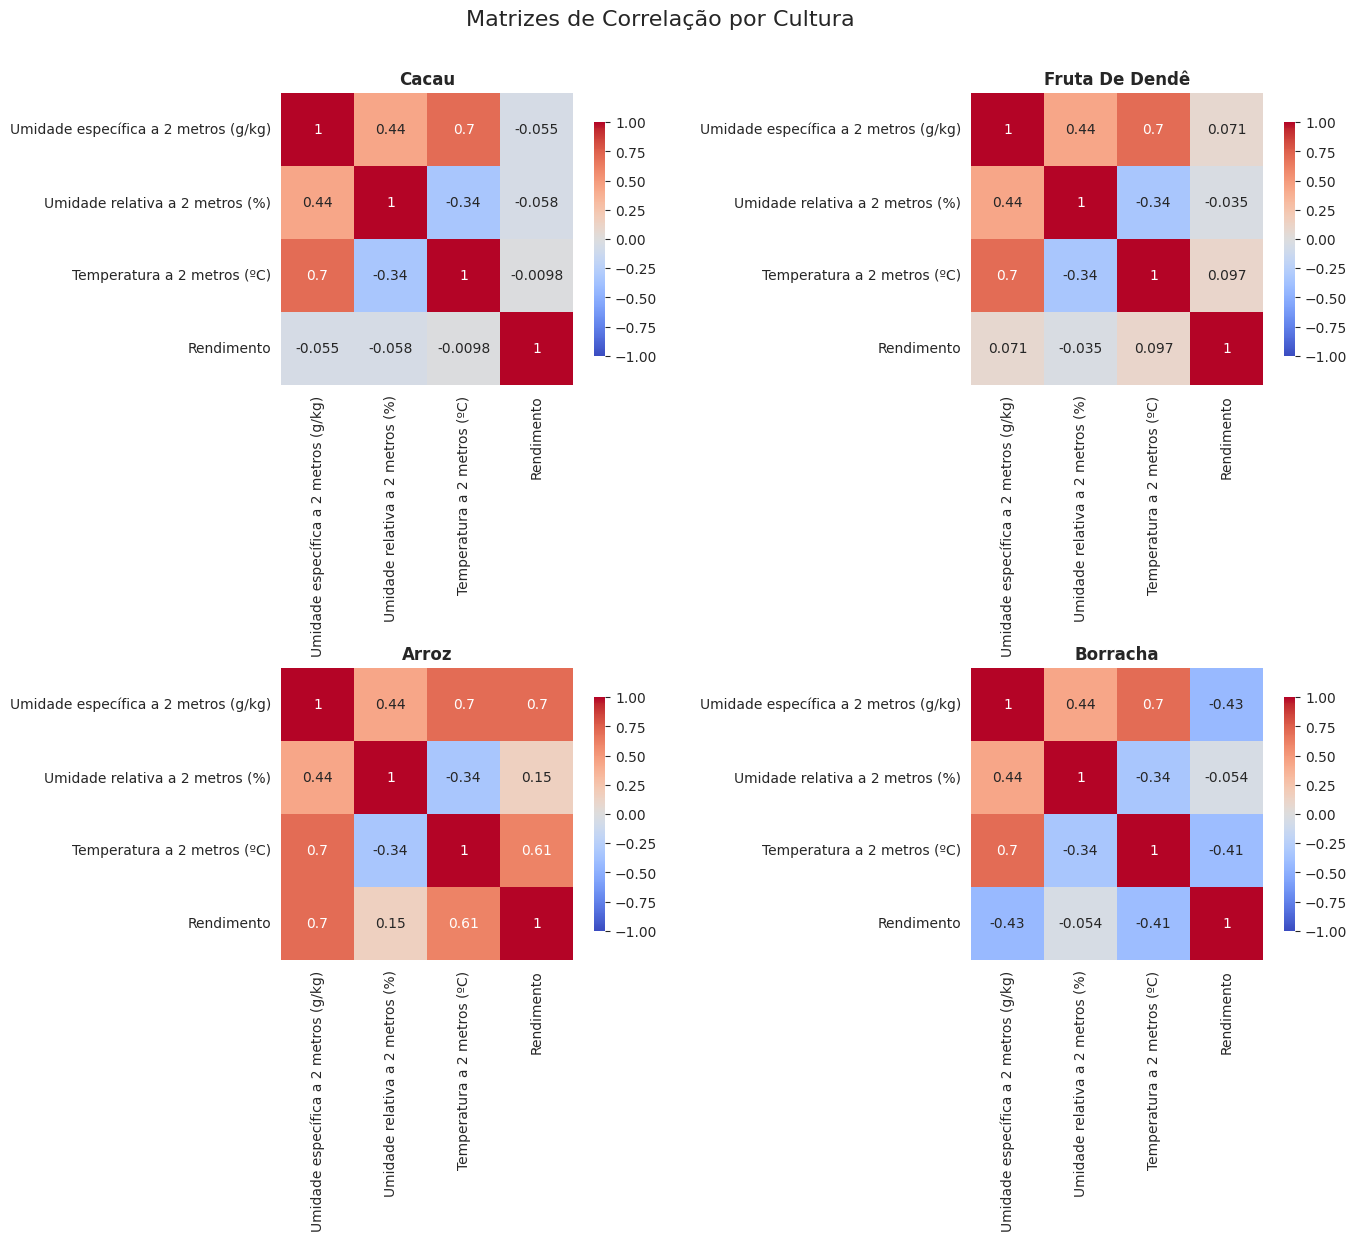


📈 CORRELAÇÕES COM RENDIMENTO POR CULTURA:
------------------------------------------------------------

🔷 Cacau:
   Temperatura a 2 metros (ºC): -0.010 
   Umidade específica a 2 metros (g/kg): -0.055 
   Umidade relativa a 2 metros (%): -0.058 

🔷 Fruta De Dendê:
   Temperatura a 2 metros (ºC): 0.097 
   Umidade específica a 2 metros (g/kg): 0.071 
   Umidade relativa a 2 metros (%): -0.035 

🔷 Arroz:
   Umidade específica a 2 metros (g/kg): 0.697 ⭐⭐⭐
   Temperatura a 2 metros (ºC): 0.609 ⭐⭐⭐
   Umidade relativa a 2 metros (%): 0.150 

🔷 Borracha:
   Umidade relativa a 2 metros (%): -0.054 
   Temperatura a 2 metros (ºC): -0.407 ⭐⭐
   Umidade específica a 2 metros (g/kg): -0.434 ⭐⭐


In [352]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variáveis para análise
variaveis = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)', 'Rendimento']

# Criar figura com subplots para cada cultura
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, cultura in enumerate(novo_df['Cultura'].unique()):
    ax = axes[i]
    # Excluir a coluna 'Cultura' para cálculo de correlação
    subset = novo_df[novo_df['Cultura'] == cultura].drop(columns=['Cultura'])[variaveis[1:]]

    # Calcular correlação
    corr = subset.corr()

    # Heatmap
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f'{cultura}', fontweight='bold')

plt.suptitle('Matrizes de Correlação por Cultura', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Mostrar correlações com Rendimento (mais importante!)
print("\n📈 CORRELAÇÕES COM RENDIMENTO POR CULTURA:")
print("-"*60)

for cultura in novo_df['Cultura'].unique():
    # Excluir a coluna 'Cultura' para cálculo de correlação
    subset = novo_df[novo_df['Cultura'] == cultura].drop(columns=['Cultura'])[variaveis[1:]]
    corr_com_rendimento = subset.corr()['Rendimento'].drop('Rendimento').sort_values(ascending=False)

    print(f"\n🔷 {cultura}:")
    for var, valor in corr_com_rendimento.items():
        # Indicador visual da força da correlação
        estrelas = '⭐' * int(abs(valor) * 5)
        print(f"   {var}: {valor:.3f} {estrelas}")

In [353]:
print("\n" + "="*70)
print("🔍 IDENTIFICANDO AS CORRELAÇÕES MAIS FORTES")
print("="*70)

# Encontrar a variável mais correlacionada com Rendimento para cada cultura
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variaveis]
    corr = subset.corr()['Rendimento'].drop('Rendimento')

    var_mais_positiva = corr.idxmax()
    var_mais_negativa = corr.idxmin()

    print(f"\n🔷 {cultura}:")
    print(f"   ✅ Mais positiva: {var_mais_positiva} (r = {corr[var_mais_positiva]:.3f})")
    print(f"   ❌ Mais negativa: {var_mais_negativa} (r = {corr[var_mais_negativa]:.3f})")

    # Interpretação
    if abs(corr[var_mais_positiva]) > 0.5:
        print(f"      → Forte relação com {var_mais_positiva}!")
    elif abs(corr[var_mais_positiva]) > 0.3:
        print(f"      → Relação moderada com {var_mais_positiva}")
    else:
        print(f"      → Relação fraca com todas as variáveis")


🔍 IDENTIFICANDO AS CORRELAÇÕES MAIS FORTES

🔷 Cacau:
   ✅ Mais positiva: Precipitação (mm dia 1) (r = 0.174)
   ❌ Mais negativa: Umidade relativa a 2 metros (%) (r = -0.058)
      → Relação fraca com todas as variáveis

🔷 Fruta De Dendê:
   ✅ Mais positiva: Precipitação (mm dia 1) (r = 0.222)
   ❌ Mais negativa: Umidade relativa a 2 metros (%) (r = -0.035)
      → Relação fraca com todas as variáveis

🔷 Arroz:
   ✅ Mais positiva: Umidade específica a 2 metros (g/kg) (r = 0.697)
   ❌ Mais negativa: Umidade relativa a 2 metros (%) (r = 0.150)
      → Forte relação com Umidade específica a 2 metros (g/kg)!

🔷 Borracha:
   ✅ Mais positiva: Precipitação (mm dia 1) (r = 0.101)
   ❌ Mais negativa: Umidade específica a 2 metros (g/kg) (r = -0.434)
      → Relação fraca com todas as variáveis


#### 5.2 Gráficos de Dispersão das Variáveis vs Rendimento


📉 GRÁFICOS DE DISPERSÃO - VARIÁVEIS vs RENDIMENTO

📊 Precipitação (mm dia 1) vs RENDIMENTO:


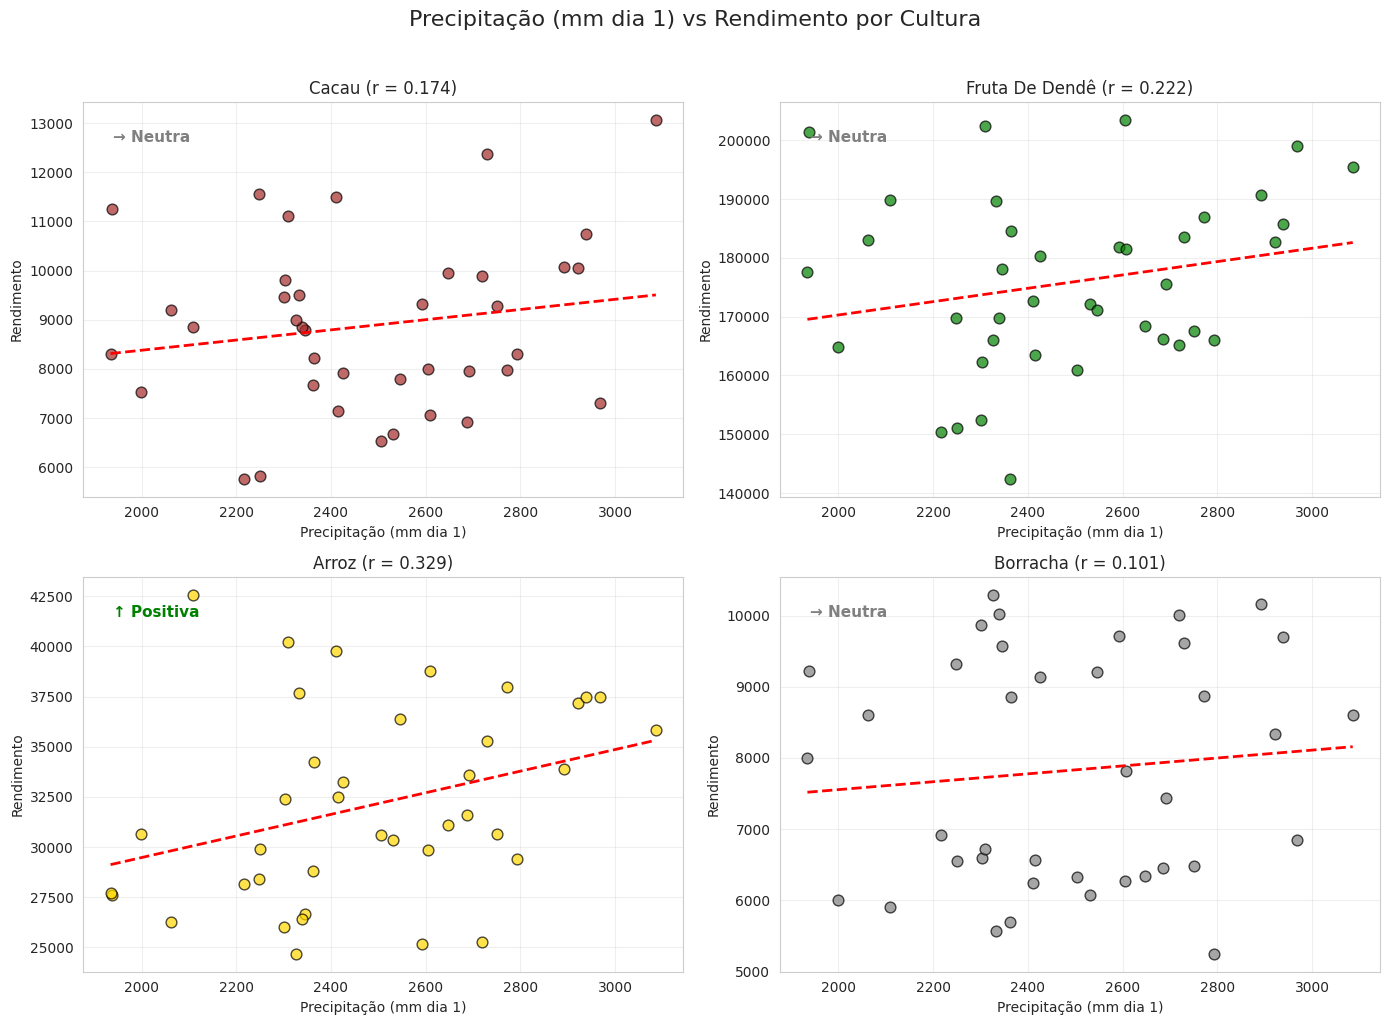


📊 Umidade específica a 2 metros (g/kg) vs RENDIMENTO:


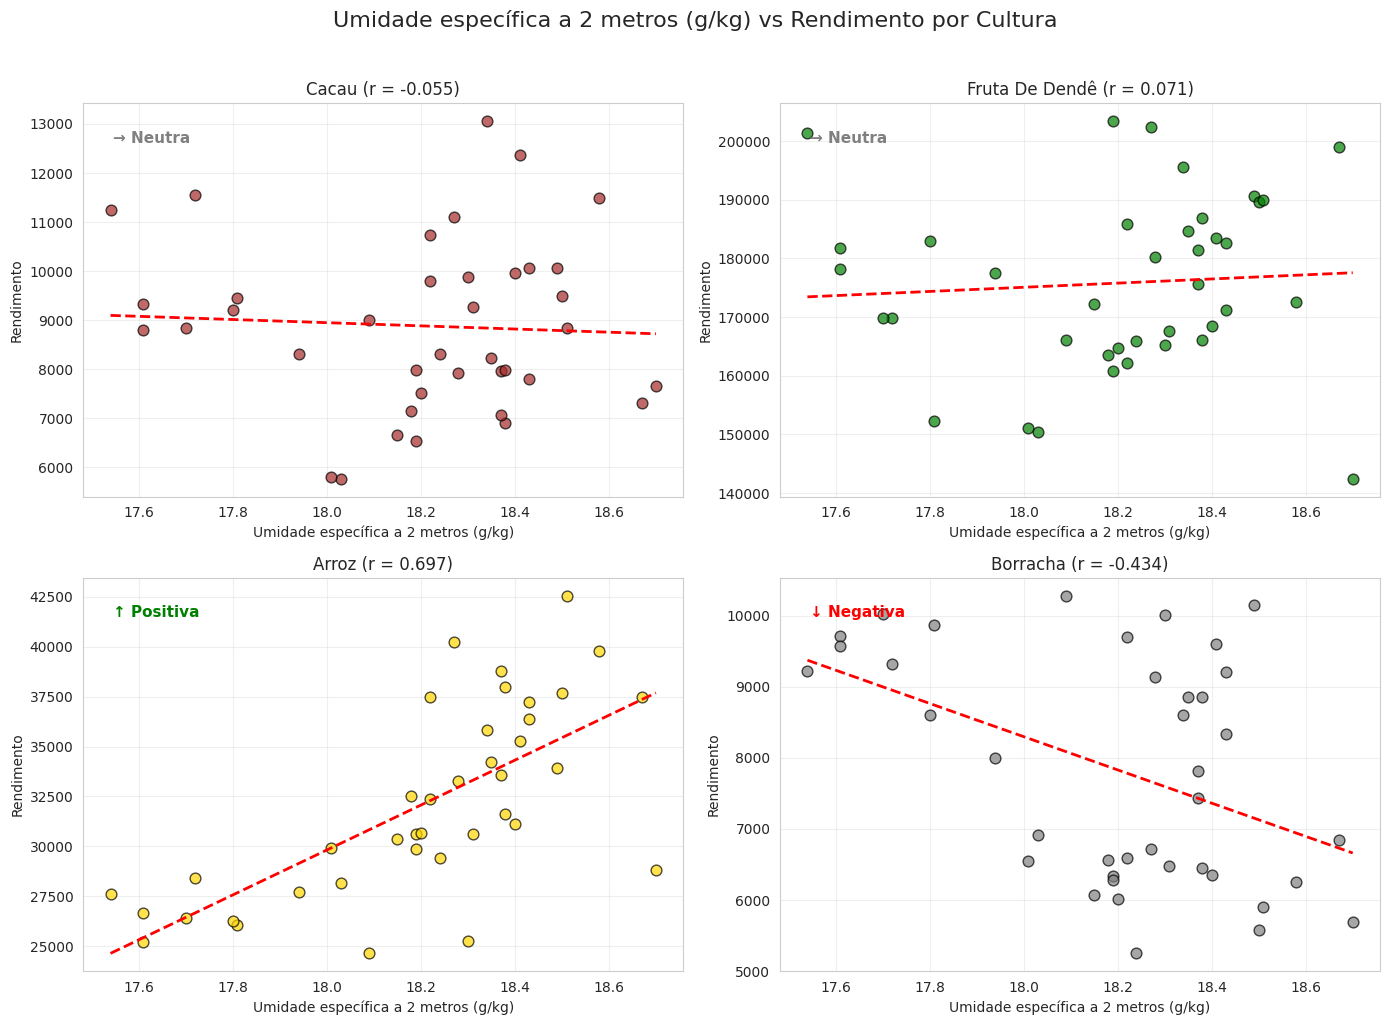


📊 Umidade relativa a 2 metros (%) vs RENDIMENTO:


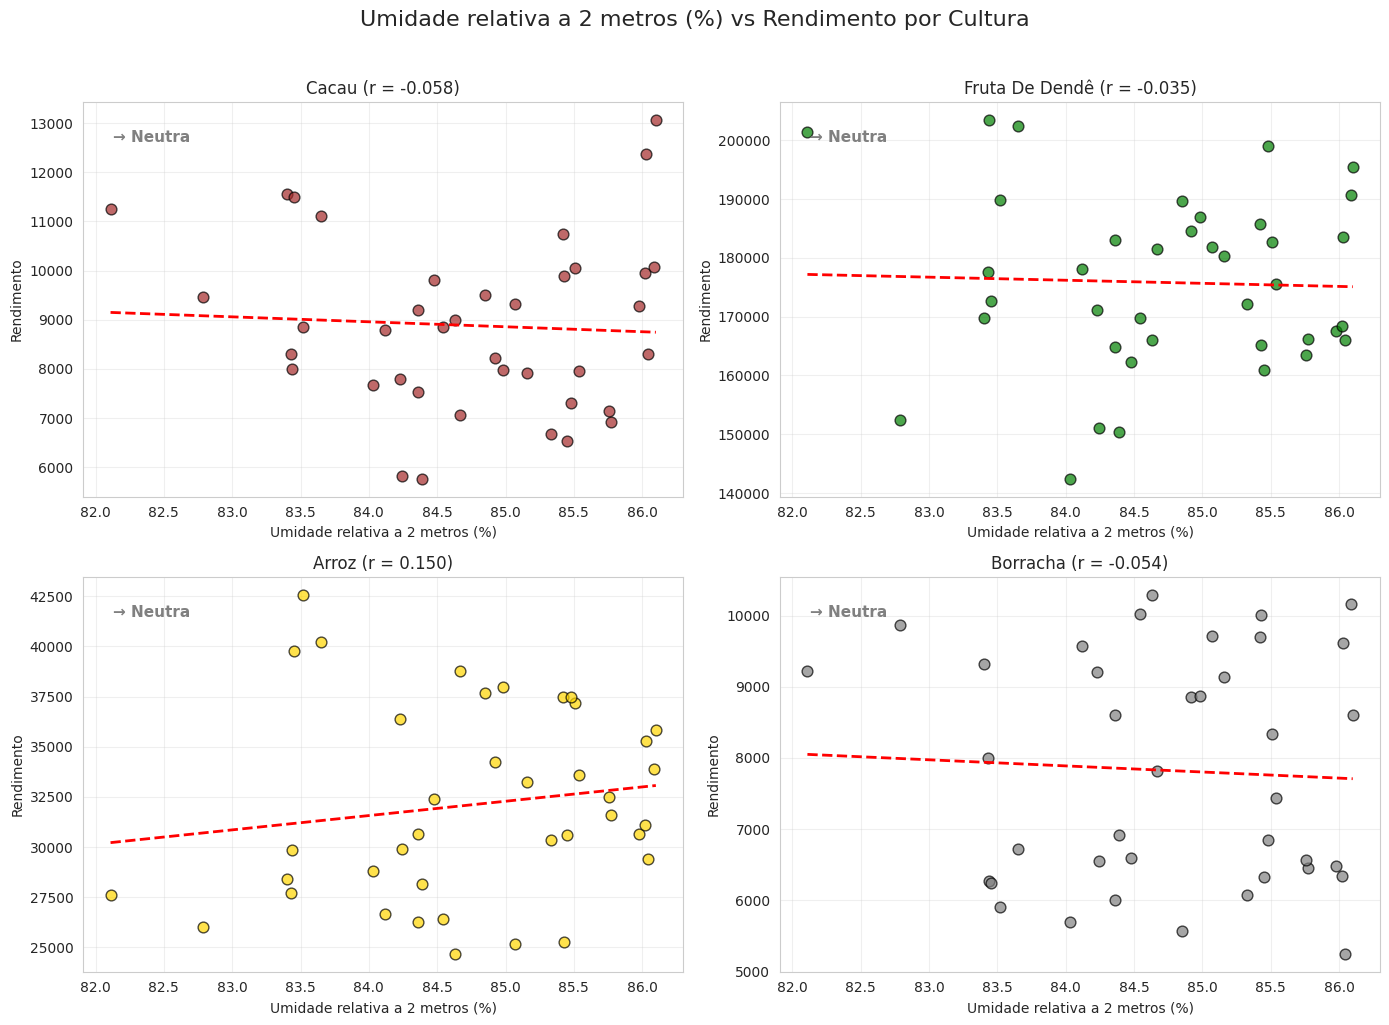


📊 Temperatura a 2 metros (ºC) vs RENDIMENTO:


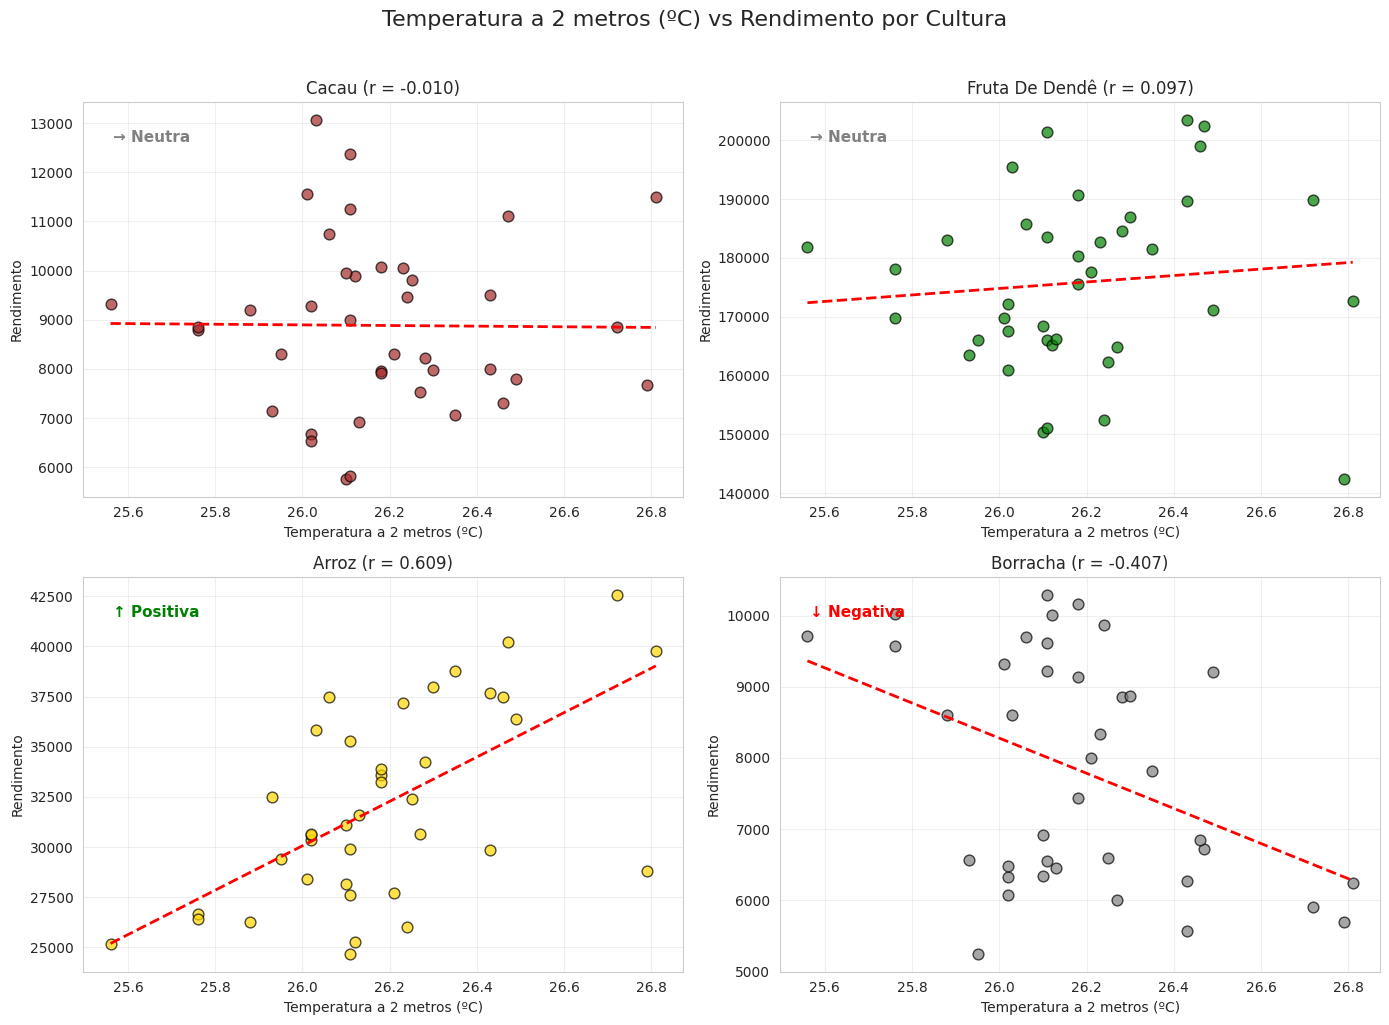

In [354]:
print("\n" + "="*70)
print("📉 GRÁFICOS DE DISPERSÃO - VARIÁVEIS vs RENDIMENTO")
print("="*70)

# Cores para cada cultura
cores = {'Cacau': 'brown', 'Fruta De Dendê': 'green',
         'Arroz': 'gold', 'Borracha': 'gray'}

# Para cada variável climática, plotar vs Rendimento
variaveis_clima = ['Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)']

for var_clima in variaveis_clima:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    print(f"\n📊 {var_clima} vs RENDIMENTO:")

    for i, cultura in enumerate(novo_df['Cultura'].unique()):
        ax = axes[i]
        subset = novo_df[novo_df['Cultura'] == cultura]

        # Scatter plot
        ax.scatter(subset[var_clima], subset['Rendimento'],
                   color=cores[cultura], alpha=0.7, s=60, edgecolor='black')

        # Linha de tendência
        z = np.polyfit(subset[var_clima], subset['Rendimento'], 1)
        p = np.poly1d(z)
        ax.plot(subset[var_clima].sort_values(),
                p(subset[var_clima].sort_values()),
                color='red', linewidth=2, linestyle='--')

        # Correlação
        corr = subset[var_clima].corr(subset['Rendimento'])

        ax.set_xlabel(var_clima)
        ax.set_ylabel('Rendimento')
        ax.set_title(f'{cultura} (r = {corr:.3f})')
        ax.grid(True, alpha=0.3)

        # Interpretação visual
        if corr > 0.3:
            ax.text(0.05, 0.9, '↑ Positiva', transform=ax.transAxes,
                   fontsize=11, color='green', fontweight='bold')
        elif corr < -0.3:
            ax.text(0.05, 0.9, '↓ Negativa', transform=ax.transAxes,
                   fontsize=11, color='red', fontweight='bold')
        else:
            ax.text(0.05, 0.9, '→ Neutra', transform=ax.transAxes,
                   fontsize=11, color='gray', fontweight='bold')

    plt.suptitle(f'{var_clima} vs Rendimento por Cultura', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

#### 5.3 Mapa de Calor das Correlações por Cultura


🔥 MAPA DE CALOR DAS CORRELAÇÕES POR CULTURA

📊 Correlações com Rendimento:
                                      Cacau  Fruta De Dendê  Arroz  Borracha
Precipitação (mm dia 1)               0.174           0.222  0.329     0.101
Umidade específica a 2 metros (g/kg) -0.055           0.071  0.697    -0.434
Umidade relativa a 2 metros (%)      -0.058          -0.035  0.150    -0.054
Temperatura a 2 metros (ºC)          -0.010           0.097  0.609    -0.407


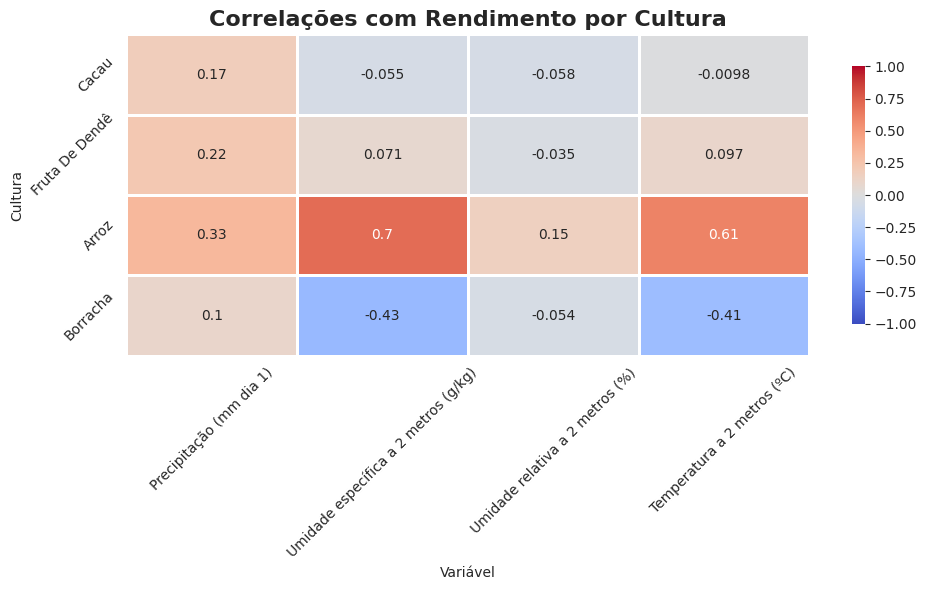

In [355]:
print("\n" + "="*70)
print("🔥 MAPA DE CALOR DAS CORRELAÇÕES POR CULTURA")
print("="*70)

# Preparar dados para o heatmap comparativo
correlacoes_df = pd.DataFrame()

for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura][variaveis]
    corr = subset.corr()['Rendimento'].drop('Rendimento')
    correlacoes_df[cultura] = corr

print("\n📊 Correlações com Rendimento:")
print(correlacoes_df.round(3))

# Heatmap comparativo
plt.figure(figsize=(10, 6))
sns.heatmap(correlacoes_df.T, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlações com Rendimento por Cultura', fontsize=16, fontweight='bold')
plt.ylabel('Cultura')
plt.yticks(rotation=45)
plt.xlabel('Variável')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5.4 Analise de Tendências


📈 ANÁLISE DE TENDÊNCIAS - PONTO ÓTIMO


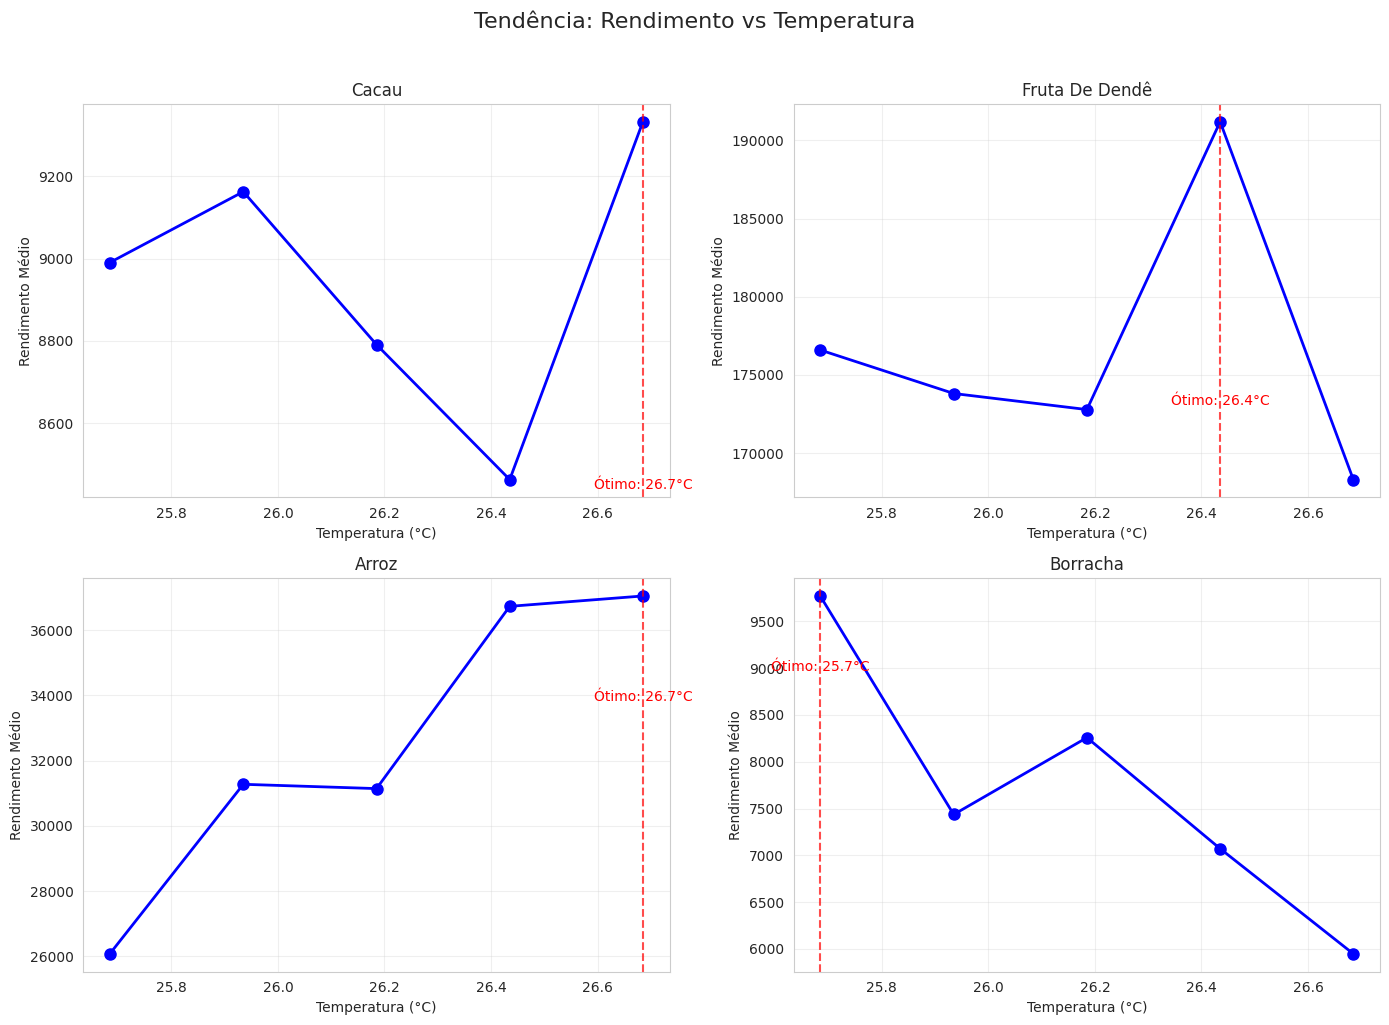

In [356]:
print("\n" + "="*70)
print("📈 ANÁLISE DE TENDÊNCIAS - PONTO ÓTIMO")
print("="*70)

# variaveis = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)', 'Rendimento']

# Verificar se existe um "ponto ótimo" de temperatura para cada cultura
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, cultura in enumerate(novo_df['Cultura'].unique()):
    ax = axes[i]
    subset = novo_df[novo_df['Cultura'] == cultura]

    # Criar faixas de temperatura
    subset['Temp_Faixa'] = pd.cut(subset['Temperatura a 2 metros (ºC)'], bins=5)

    # Calcular rendimento médio por faixa
    tendencia = subset.groupby('Temp_Faixa')['Rendimento'].mean().reset_index()
    tendencia['Temp_Media'] = tendencia['Temp_Faixa'].apply(lambda x: x.mid)

    # Plotar
    ax.plot(tendencia['Temp_Media'], tendencia['Rendimento'],
            marker='o', linewidth=2, markersize=8, color='blue')
    ax.set_xlabel('Temperatura (°C)')
    ax.set_ylabel('Rendimento Médio')
    ax.set_title(f'{cultura}')
    ax.grid(True, alpha=0.3)

    # Encontrar ponto ótimo (se existir)
    ponto_otimo = tendencia.loc[tendencia['Rendimento'].idxmax(), 'Temp_Media']
    ax.axvline(x=ponto_otimo, color='red', linestyle='--', alpha=0.7)
    ax.text(ponto_otimo, ax.get_ylim()[1]*0.9, f'Ótimo: {ponto_otimo:.1f}°C',
            ha='center', color='red')

plt.suptitle('Tendência: Rendimento vs Temperatura', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 5.5 Observações da Analise Multivariada

### a. **Variável mais Influente para cada Cultura**

| Cultura | Variável mais relevante | Correlação (r) |
|---------|------------------------|----------------|
| Cacau   | Precipitação (mm dia 1) | 0,174 |
| Fruta de Dendê | Precipitação (mm dia 1) | 0,222 |
| Arroz   | Umidade específica a 2 metros (g/kg) | 0,697 |
| Borracha | Umidade específica a 2 metros (g/kg) | -0,434 |

### b. **Cultura mais Sensível às Variáveis Climáticas**
(média das correlações absolutas com o rendimento)

| Cultura | Sensibilidade Média |
|---------|---------------------|
| Arroz   | 0,446 |
| Borracha | 0,249 |
| Fruta de Dendê | 0,106 |
| Cacau   | 0,074 |

### c. **Padrões Consistentes entre Culturas**

| Variável | Comportamento |
|----------|---------------|
| **Precipitação (mm dia 1)** | ✅ Mesma direção para todas as culturas (**positiva**) |
| **Umidade específica a 2 metros (g/kg)** | ⚠️ Direção **varia entre culturas** |
| **Umidade relativa a 2 metros (%)** | ⚠️ Direção **varia entre culturas** |
| **Temperatura a 2 metros (ºC)** | ⚠️ Direção **varia entre culturas** |

### d. **Interpretação**

- O **Arroz** é a cultura mais sensível às variações climáticas, especialmente à **umidade específica** (r = 0,697), que apresenta correlação positiva forte.
- A **Borracha** também responde à umidade específica, mas de forma **negativa** (r = -0,434), indicando que prefere condições menos úmidas.
- A **precipitação** tem efeito positivo em todas as culturas, embora fraco para Cacau e Fruta de Dendê.
- **Cacau** e **Fruta de Dendê** apresentam baixíssima sensibilidade climática (média < 0,11), sugerindo que seu rendimento é determinado quase exclusivamente por fatores não climáticos (genética, manejo, solo).

Esses resultados reforçam que **cada cultura responde de forma única** às condições ambientais, e que modelos preditivos devem considerar essas especificidades.

In [357]:
print("\n" + "="*70)
print(" PRINCIPAIS DESCOBERTAS")
print("="*70)

# 1. Qual variável mais influencia cada cultura?
print("\n1. VARIÁVEL MAIS INFLUENTE POR CULTURA:")

for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura]
    corrs = {var: subset[var].corr(subset['Rendimento']) for var in variaveis_clima}
    var_mais_influente = max(corrs, key=lambda x: abs(corrs[x]))
    print(f"   • {cultura}: {var_mais_influente} (r = {corrs[var_mais_influente]:.3f})")

# 2. Cultura mais sensível a variações climáticas
print("\n2. CULTURA MAIS SENSÍVEL (maior |correlação| média):")

sensibilidade = []
for cultura in novo_df['Cultura'].unique():
    subset = novo_df[novo_df['Cultura'] == cultura]
    corr_media = np.mean([abs(subset[var].corr(subset['Rendimento'])) for var in variaveis_clima])
    sensibilidade.append((cultura, corr_media))

# Ordenar decrescente
sensibilidade.sort(key=lambda x: x[1], reverse=True)

for cultura, valor in sensibilidade:
    print(f"   • {cultura}: {valor:.3f}")

# 3. Padrões consistentes entre culturas
print("\n3. PADRÕES CONSISTENTES:")

for var in variaveis_clima:
    sinais = []
    for cultura in novo_df['Cultura'].unique():
        subset = novo_df[novo_df['Cultura'] == cultura]
        corr = subset[var].corr(subset['Rendimento'])
        sinais.append(np.sign(corr))

    if all(s == sinais[0] for s in sinais):
        direcao = "positiva" if sinais[0] > 0 else "negativa" if sinais[0] < 0 else "zero"
        print(f"   • {var}: mesma direção para todas as culturas ({direcao})")
    else:
        print(f"   • {var}: direção varia entre culturas")


 PRINCIPAIS DESCOBERTAS

1. VARIÁVEL MAIS INFLUENTE POR CULTURA:
   • Cacau: Precipitação (mm dia 1) (r = 0.174)
   • Fruta De Dendê: Precipitação (mm dia 1) (r = 0.222)
   • Arroz: Umidade específica a 2 metros (g/kg) (r = 0.697)
   • Borracha: Umidade específica a 2 metros (g/kg) (r = -0.434)

2. CULTURA MAIS SENSÍVEL (maior |correlação| média):
   • Arroz: 0.446
   • Borracha: 0.249
   • Fruta De Dendê: 0.106
   • Cacau: 0.074

3. PADRÕES CONSISTENTES:
   • Precipitação (mm dia 1): mesma direção para todas as culturas (positiva)
   • Umidade específica a 2 metros (g/kg): direção varia entre culturas
   • Umidade relativa a 2 metros (%): direção varia entre culturas
   • Temperatura a 2 metros (ºC): direção varia entre culturas


## 6. Conclusão EDA


### 6.1. VISÃO GERAL DO DATASET
- **Número de observações:** 156  
- **Número de variáveis:** 6  
- **Culturas:** Cacau, Fruta De Dendê, Arroz, Borracha  



### 6.2. ANÁLISE UNIVARIADA – PRINCIPAIS DESCOBERTAS

#### a. Rendimento (Yield) por cultura
- **Arroz:** rendimento médio = 32100 (desvio = 4790)  
- **Borracha:** rendimento médio = 7825 (desvio = 1600)  
- **Cacau:** rendimento médio = 8883 (desvio = 1745)  
- **Fruta De Dendê:** rendimento médio = 175805 (desvio = 14920)  
- **Cultura mais estável (menor CV%):** Fruta De Dendê (CV% = 8.5%)  
- **Cultura mais variável (maior CV%):** Borracha (CV% = 20.5%)

#### b. Condições climáticas por cultura
- **Temperatura média por cultura:**  
  - Arroz: 26.18°C (min: 25.56, max: 26.81)  
  - Borracha: 26.18°C (min: 25.56, max: 26.81)  
  - Cacau: 26.18°C (min: 25.56, max: 26.81)  
  - Fruta De Dendê: 26.18°C (min: 25.56, max: 26.81)  

- **Precipitação média por cultura:**  
  - Arroz: 2486 mm/dia (min: 1935, max: 3086)  
  - Borracha: 2486 mm/dia (min: 1935, max: 3086)  
  - Cacau: 2486 mm/dia (min: 1935, max: 3086)  
  - Fruta De Dendê: 2486 mm/dia (min: 1935, max: 3086)  

- **Umidade específica média por cultura:**  
  - Arroz: 18.20 g/kg (min: 17.54, max: 18.70)  
  - Borracha: 18.20 g/kg (min: 17.54, max: 18.70)  
  - Cacau: 18.20 g/kg (min: 17.54, max: 18.70)  
  - Fruta De Dendê: 18.20 g/kg (min: 17.54, max: 18.70)  

- **Umidade relativa média por cultura:**  
  - Arroz: 84.7% (min: 82.1, max: 86.1)  
  - Borracha: 84.7% (min: 82.1, max: 86.1)  
  - Cacau: 84.7% (min: 82.1, max: 86.1)  
  - Fruta De Dendê: 84.7% (min: 82.1, max: 86.1)  

- **Observação:** As variáveis climáticas apresentam **BAIXA VARIABILIDADE** entre as culturas. As médias são muito próximas, indicando que todas foram expostas a condições climáticas similares.


### 6.3. ANÁLISE MULTIVARIADA – PRINCIPAIS DESCOBERTAS

#### a. Correlações globais
- As correlações entre variáveis climáticas e rendimento são **FRACAS** quando consideramos todas as culturas juntas.  
- A variável mais correlacionada com rendimento (geral) é **Precipitação (mm dia 1)** (r = 0.019)

#### b. Correlações por cultura (mais relevante)
- **Cacau:**  
  - Variável mais relevante: Precipitação (mm dia 1) (r = 0.174)  
  - Padrão: positivo  
- **Fruta De Dendê:**  
  - Variável mais relevante: Precipitação (mm dia 1) (r = 0.222)  
  - Padrão: positivo  
- **Arroz:**  
  - Variável mais relevante: Umidade específica a 2 metros (g/kg) (r = 0.697)  
  - Padrão: positivo  
- **Borracha:**  
  - Variável mais relevante: Umidade específica a 2 metros (g/kg) (r = -0.434)  
  - Padrão: negativo  

#### c. Relações entre variáveis climáticas
- Forte correlação positiva entre umidade específica e umidade relativa (r = 0.44)  
- Correlação negativa moderada entre temperatura e umidade relativa (r = -0.34)  
- Precipitação tem correlação fraca com as demais variáveis (valores < 0.3)


### 6.4. OBSERVAÇÕES IMPORTANTES

#### a. Homogeneidade climática
- As quatro culturas foram expostas a condições climáticas **MUITO SIMILARES**  
- Isto significa que as diferenças de rendimento **NÃO podem ser atribuídas ao clima**  
- Fatores como genética, solo e manejo provavelmente explicam as diferenças


### 6.5. IMPLICAÇÕES PARA A MODELAGEM

#### a. Oportunidades
- A segmentação por cultura é **ESSENCIAL** – modelos globais podem ser enganosos  
- As variáveis climáticas, embora similares, ainda podem ter efeitos sutis

#### b. Dificuldades
- A homogeneidade dos dados climáticos pode limitar a capacidade preditiva  



In [358]:
print("="*80)
print(" RELATÓRIO DE ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("="*80)

# Definir os nomes das colunas (certifique-se de que estão corretos no seu DataFrame)
col_precip = 'Precipitação (mm dia 1)'
col_umid_esp = 'Umidade específica a 2 metros (g/kg)'
col_umid_rel = 'Umidade relativa a 2 metros (%)'
col_temp = 'Temperatura a 2 metros (ºC)'
col_rend = 'Rendimento'
col_cultura = 'Cultura'

# Lista de variáveis climáticas
variaveis_clima = [col_precip, col_temp, col_umid_esp, col_umid_rel]

# 1. Visão geral
print(f"""
1. VISÃO GERAL DO DATASET
   • Número de observações: {len(novo_df)}
   • Número de variáveis: {len(novo_df.columns)}
   • Culturas: {', '.join(novo_df[col_cultura].unique())}
""")

# 2. Análise univariada - rendimento por cultura
rend_por_cultura = novo_df.groupby(col_cultura)[col_rend].agg(['mean', 'std'])
rend_por_cultura['CV%'] = (rend_por_cultura['std'] / rend_por_cultura['mean']) * 100

print("2. ANÁLISE UNIVARIADA - PRINCIPAIS DESCOBERTAS\n")
print("   2.1 RENDIMENTO (YIELD) POR CULTURA:")
for cultura in rend_por_cultura.index:
    print(f"   • {cultura}: rendimento médio = {rend_por_cultura.loc[cultura, 'mean']:.0f} (desvio = {rend_por_cultura.loc[cultura, 'std']:.0f})")

cultura_estavel = rend_por_cultura['CV%'].idxmin()
cultura_variavel = rend_por_cultura['CV%'].idxmax()
print(f"\n   • Cultura mais estável (menor CV%): {cultura_estavel} (CV% = {rend_por_cultura.loc[cultura_estavel, 'CV%']:.1f}%)")
print(f"   • Cultura mais variável (maior CV%): {cultura_variavel} (CV% = {rend_por_cultura.loc[cultura_variavel, 'CV%']:.1f}%)")

# 2.2 Condições climáticas por cultura
print("\n   2.2 CONDIÇÕES CLIMÁTICAS POR CULTURA:")

# Temperatura
temp_por_cultura = novo_df.groupby(col_cultura)[col_temp].agg(['mean', 'min', 'max'])
print(f"\n   • Temperatura média por cultura:")
for cultura in temp_por_cultura.index:
    print(f"      - {cultura}: {temp_por_cultura.loc[cultura, 'mean']:.2f}°C (min: {temp_por_cultura.loc[cultura, 'min']:.2f}, max: {temp_por_cultura.loc[cultura, 'max']:.2f})")

# Precipitação
precip_por_cultura = novo_df.groupby(col_cultura)[col_precip].agg(['mean', 'min', 'max'])
print(f"\n   • Precipitação média por cultura:")
for cultura in precip_por_cultura.index:
    print(f"      - {cultura}: {precip_por_cultura.loc[cultura, 'mean']:.0f} mm/dia (min: {precip_por_cultura.loc[cultura, 'min']:.0f}, max: {precip_por_cultura.loc[cultura, 'max']:.0f})")

# Umidade específica
umid_esp_por_cultura = novo_df.groupby(col_cultura)[col_umid_esp].agg(['mean', 'min', 'max'])
print(f"\n   • Umidade específica média por cultura:")
for cultura in umid_esp_por_cultura.index:
    print(f"      - {cultura}: {umid_esp_por_cultura.loc[cultura, 'mean']:.2f} g/kg (min: {umid_esp_por_cultura.loc[cultura, 'min']:.2f}, max: {umid_esp_por_cultura.loc[cultura, 'max']:.2f})")

# Umidade relativa
umid_rel_por_cultura = novo_df.groupby(col_cultura)[col_umid_rel].agg(['mean', 'min', 'max'])
print(f"\n   • Umidade relativa média por cultura:")
for cultura in umid_rel_por_cultura.index:
    print(f"      - {cultura}: {umid_rel_por_cultura.loc[cultura, 'mean']:.1f}% (min: {umid_rel_por_cultura.loc[cultura, 'min']:.1f}, max: {umid_rel_por_cultura.loc[cultura, 'max']:.1f})")

print(f"""
   • Observação: As variáveis climáticas apresentam BAIXA VARIABILIDADE entre as culturas.
     As médias são muito próximas, indicando que todas foram expostas a condições climáticas similares.
""")

# 3. Análise multivariada
print("3. ANÁLISE MULTIVARIADA - PRINCIPAIS DESCOBERTAS\n")

# 3.1 Correlações globais
corr_global = novo_df[variaveis_clima + [col_rend]].corr()[col_rend].drop(col_rend)
var_mais_corr_global = corr_global.abs().idxmax()
print(f"   3.1 CORRELAÇÕES GLOBAIS:")
print(f"   • As correlações entre variáveis climáticas e rendimento são FRACAS quando consideramos todas as culturas juntas.")
print(f"   • A variável mais correlacionada com rendimento (geral) é {var_mais_corr_global} (r = {corr_global[var_mais_corr_global]:.3f})")

# 3.2 Correlações por cultura
print("\n   3.2 CORRELAÇÕES POR CULTURA (MAIS RELEVANTE):")
for cultura in novo_df[col_cultura].unique():
    subset = novo_df[novo_df[col_cultura] == cultura]
    corrs = subset[variaveis_clima].corrwith(subset[col_rend])
    if not corrs.empty:
        var_principal = corrs.abs().idxmax()
        sinal = 'positivo' if corrs[var_principal] > 0 else 'negativo'
        print(f"""
   • {cultura}:
     - Variável mais relevante: {var_principal} (r = {corrs[var_principal]:.3f})
     - Padrão: {sinal}""")

# 3.3 Relações entre variáveis climáticas
print("\n   3.3 RELAÇÕES ENTRE VARIÁVEIS CLIMÁTICAS:")
corr_umid_esp_umid_rel = novo_df[col_umid_esp].corr(novo_df[col_umid_rel])
corr_temp_umid_rel = novo_df[col_temp].corr(novo_df[col_umid_rel])
print(f"   • Forte correlação positiva entre umidade específica e umidade relativa (r = {corr_umid_esp_umid_rel:.2f})")
print(f"   • Correlação negativa moderada entre temperatura e umidade relativa (r = {corr_temp_umid_rel:.2f})")
print(f"   • Precipitação tem correlação fraca com as demais variáveis (valores < 0.3)")

# 4. Observações importantes
print("""
4. OBSERVAÇÕES IMPORTANTES

   4.1 HOMOGENEIDADE CLIMÁTICA:
   • As quatro culturas foram expostas a condições climáticas MUITO SIMILARES
   • Isto significa que as diferenças de rendimento NÃO podem ser atribuídas ao clima
   • Fatores como genética, solo e manejo provavelmente explicam as diferenças

5. IMPLICAÇÕES PARA A MODELAGEM

   5.1 OPORTUNIDADES:
   • A segmentação por cultura é ESSENCIAL - modelos globais podem ser enganosos
   • As variáveis climáticas, embora similares, ainda podem ter efeitos sutis

   5.2 DIFICULDADES:
   • A homogeneidade dos dados climáticos pode limitar a capacidade preditiva
   • Modelos podem precisar de features adicionais (interações, termos polinomiais)

""")

 RELATÓRIO DE ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

1. VISÃO GERAL DO DATASET
   • Número de observações: 156
   • Número de variáveis: 6
   • Culturas: Cacau, Fruta De Dendê, Arroz, Borracha

2. ANÁLISE UNIVARIADA - PRINCIPAIS DESCOBERTAS

   2.1 RENDIMENTO (YIELD) POR CULTURA:
   • Arroz: rendimento médio = 32100 (desvio = 4790)
   • Borracha: rendimento médio = 7825 (desvio = 1600)
   • Cacau: rendimento médio = 8883 (desvio = 1745)
   • Fruta De Dendê: rendimento médio = 175805 (desvio = 14920)

   • Cultura mais estável (menor CV%): Fruta De Dendê (CV% = 8.5%)
   • Cultura mais variável (maior CV%): Borracha (CV% = 20.5%)

   2.2 CONDIÇÕES CLIMÁTICAS POR CULTURA:

   • Temperatura média por cultura:
      - Arroz: 26.18°C (min: 25.56, max: 26.81)
      - Borracha: 26.18°C (min: 25.56, max: 26.81)
      - Cacau: 26.18°C (min: 25.56, max: 26.81)
      - Fruta De Dendê: 26.18°C (min: 25.56, max: 26.81)

   • Precipitação média por cultura:
      - Arroz: 2486 mm/dia (min: 1935, max: 3

## 7. Preparação dos dados para criação do modelo

### 7.1 Features e Target

In [359]:
# Para machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Configuração de estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Supondo que seu DataFrame já esteja carregado e limpo com o nome 'novo_df'
# Exemplo: novo_df = pd.read_csv('crop_yield_clean.csv')
# Vamos verificar as primeiras linhas
print("📌 Dados disponíveis:")
display(novo_df.head())
print("\nColunas:", novo_df.columns.tolist())

📌 Dados disponíveis:


,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,Cacau,2248.92,17.72,83.40,26.01,11560
1,Cacau,1938.42,17.54,82.11,26.11,11253
2,Cacau,2301.54,17.81,82.79,26.24,9456
3,Cacau,2592.35,17.61,85.07,25.56,9321
4,Cacau,2344.72,17.61,84.12,25.76,8800



Colunas: ['Cultura', 'Precipitação (mm dia 1)', 'Umidade específica a 2 metros (g/kg)', 'Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)', 'Rendimento']


In [360]:
# ============================================================
# 2. DEFINIÇÃO DE FEATURES E TARGET, ONE-HOT ENCODING E ESCALONAMENTO
# ============================================================

# 1. Definir features e target
features_climaticas = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)']
target = 'Rendimento'

# 2. One-Hot Encoding
cultura_dummies = pd.get_dummies(novo_df['Cultura'], prefix='Cultura', drop_first=True)

# 3. Concatenar features (climáticas + dummies)
X = pd.concat([novo_df[features_climaticas], cultura_dummies], axis=1)
y = novo_df[target]


print("✅ Features após encoding:")
print(X.head())
print(f"\nDimensões: {X.shape}")
print(f"Target: {y.name}")

✅ Features após encoding:
   Precipitação (mm dia 1)  Umidade específica a 2 metros (g/kg)  \
0                  2248.92                                 17.72   
1                  1938.42                                 17.54   
2                  2301.54                                 17.81   
3                  2592.35                                 17.61   
4                  2344.72                                 17.61   

   Umidade relativa a 2 metros (%)  Temperatura a 2 metros (ºC)  \
0                            83.40                        26.01   
1                            82.11                        26.11   
2                            82.79                        26.24   
3                            85.07                        25.56   
4                            84.12                        25.76   

   Cultura_Borracha  Cultura_Cacau  Cultura_Fruta De Dendê  
0             False           True                   False  
1             False           True      

### 7.2 Divisão de Treino e Teste

In [361]:
# ============================================================
# 3. PADRONIZAÇÃO E DIVISÃO EM TREINO E TESTE
# ============================================================

# 4. Dividir em treino e teste (antes do escalonamento!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Escalonamento: ajustar no TREINO e transformar ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"✅ Dados preparados:")
print(f"   Treino: {X_train.shape[0]} amostras")
print(f"   Teste: {X_test.shape[0]} amostras")

✅ Dados preparados:
   Treino: 124 amostras
   Teste: 32 amostras


In [362]:
# ============================================================
# 6. MODELAGEM PREDITIVA - 5 ALGORITMOS
# ============================================================

# Dicionário de modelos
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}
# Lista para guardar resultados
resultados = []

for nome, modelo in modelos.items():
    # Treinar
    modelo.fit(X_train, y_train)

    # Predizer
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Calcular métricas
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Guardar
    resultados.append({
        'Modelo': nome,
        'MSE Treino': mse_train,
        'MSE Teste': mse_test,
        'MAE Teste': mae_test,
        'R² Teste': r2_test
    })

    print(f"✅ {nome} treinado.")

# Exibir tabela comparativa
df_resultados = pd.DataFrame(resultados).round(3)
print("\n📋 Comparação dos Modelos:")
print(df_resultados.sort_values('R² Teste', ascending=False))

✅ Regressão Linear treinado.
✅ Árvore de Decisão treinado.
✅ Random Forest treinado.
✅ Gradient Boosting treinado.
✅ SVR treinado.

📋 Comparação dos Modelos:
              Modelo    MSE Treino     MSE Teste  MAE Teste  R² Teste
0   Regressão Linear  6.644201e+07  1.930869e+07   3132.796     0.995
2      Random Forest  8.920839e+06  2.407697e+07   2841.612     0.994
1  Árvore de Decisão  0.000000e+00  2.926666e+07   3239.719     0.992
3  Gradient Boosting  4.074645e+06  3.631989e+07   3264.521     0.991
4                SVR  7.261124e+09  5.085638e+09  38974.582    -0.311


### 7.3 Gráficos de desempenho dos modelos com dados de cultura no treinamento

* Os modelos supervisionados atingiram excelente capacidade preditiva graças à inclusão da variável cultura, confirmando que esta é a principal determinante do rendimento. A **Regressão Linear** e o **Random Fores**t destacam-se como as melhores opções, com R² > 0,99 e erros absolutos na ordem de 2.800–3.200 unidades. Esses resultados são consistentes com a análise exploratória e atendem ao objetivo de construir modelos preditivos para o rendimento das safras.

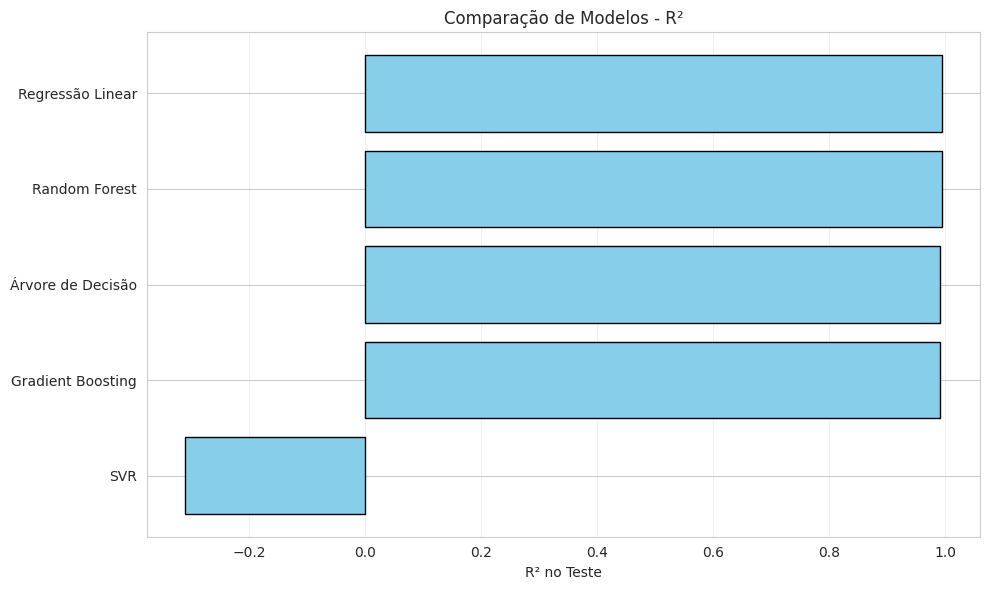

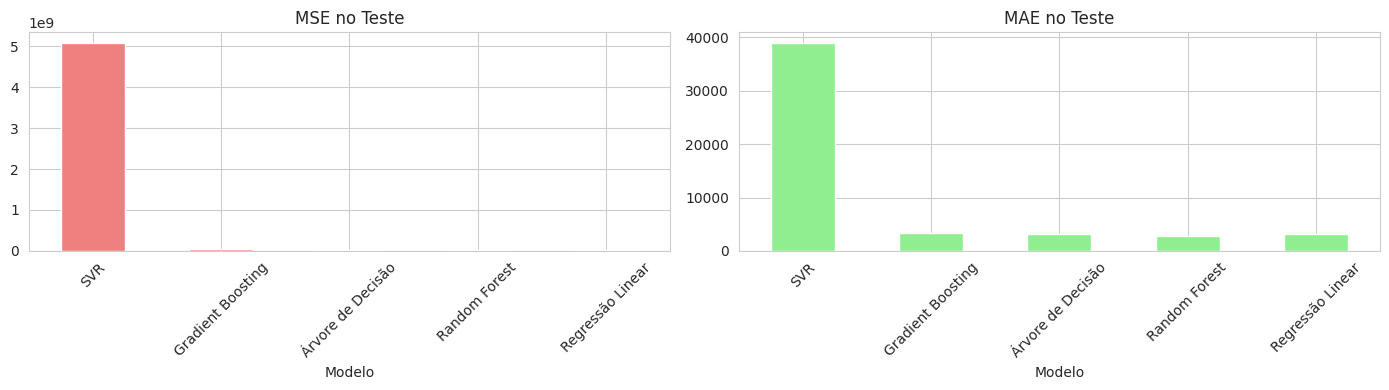

In [363]:
# ============================================================
# 7. GRÁFICO COMPARATIVO DOS MODELOS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
df_resultados_sorted = df_resultados.sort_values('R² Teste', ascending=True)

# Barras horizontais para R²
ax.barh(df_resultados_sorted['Modelo'], df_resultados_sorted['R² Teste'],
        color='skyblue', edgecolor='black')
ax.set_xlabel('R² no Teste')
ax.set_title('Comparação de Modelos - R²')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico de barras para MSE e MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_resultados_sorted.plot(x='Modelo', y='MSE Teste', kind='bar', ax=axes[0],
                          color='lightcoral', legend=False)
axes[0].set_title('MSE no Teste')
axes[0].tick_params(axis='x', rotation=45)

df_resultados_sorted.plot(x='Modelo', y='MAE Teste', kind='bar', ax=axes[1],
                          color='lightgreen', legend=False)
axes[1].set_title('MAE no Teste')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* Os modelos supervisionados atingiram excelente capacidade preditiva graças à inclusão da variável cultura, confirmando que esta é a principal determinante do rendimento. A **Regressão Linear** e o **Random Fores**t destacam-se como as melhores opções, com R² > 0,99 e erros absolutos na ordem de 2.800–3.200 unidades. Esses resultados são consistentes com a análise exploratória e atendem ao objetivo de construir modelos preditivos para o rendimento das safras.

### Treinamento dos modelos sem dados de cultura no treinamento

In [364]:
# ============================================================
# MODELAGEM APENAS COM VARIÁVEIS CLIMÁTICAS (SEM CULTURA)
# ============================================================

# 1. Features apenas climáticas
features_climaticas = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)']
target = 'Rendimento'

X_clim = novo_df[features_climaticas]
y_clim = novo_df[target]

# 2. Divisão treino-teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clim, y_clim, test_size=0.2, random_state=42
)

# 3. Escalonamento (ajustado no treino)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 4. Modelos (mesmos anteriores)
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

# 5. Treinar e avaliar
resultados_clim = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_c_scaled, y_train_c)

    y_pred_train = modelo.predict(X_train_c_scaled)
    y_pred_test = modelo.predict(X_test_c_scaled)

    mse_train = mean_squared_error(y_train_c, y_pred_train)
    mse_test = mean_squared_error(y_test_c, y_pred_test)
    mae_test = mean_absolute_error(y_test_c, y_pred_test)
    r2_test = r2_score(y_test_c, y_pred_test)

    resultados_clim.append({
        'Modelo': nome,
        'MSE Treino': mse_train,
        'MSE Teste': mse_test,
        'MAE Teste': mae_test,
        'R² Teste': r2_test
    })

    print(f"✅ {nome} treinado (sem cultura).")

# 6. Resultados
df_resultados_clim = pd.DataFrame(resultados_clim).round(3)
print("\n📋 Comparação dos Modelos (apenas clima):")
print(df_resultados_clim.sort_values('R² Teste', ascending=False))

✅ Regressão Linear treinado (sem cultura).
✅ Árvore de Decisão treinado (sem cultura).
✅ Random Forest treinado (sem cultura).
✅ Gradient Boosting treinado (sem cultura).
✅ SVR treinado (sem cultura).

📋 Comparação dos Modelos (apenas clima):
              Modelo    MSE Treino     MSE Teste  MAE Teste  R² Teste
0   Regressão Linear  5.147449e+09  4.162256e+09  55423.349    -0.073
4                SVR  7.261225e+09  5.085748e+09  38974.921    -0.311
2      Random Forest  4.844527e+09  7.405960e+09  72215.166    -0.909
3  Gradient Boosting  4.816259e+09  8.312346e+09  75213.695    -1.143
1  Árvore de Decisão  4.815369e+09  8.525193e+09  75914.271    -1.198


### Gráficos de desempenho dos modelos sem dados de cultura no treinamento

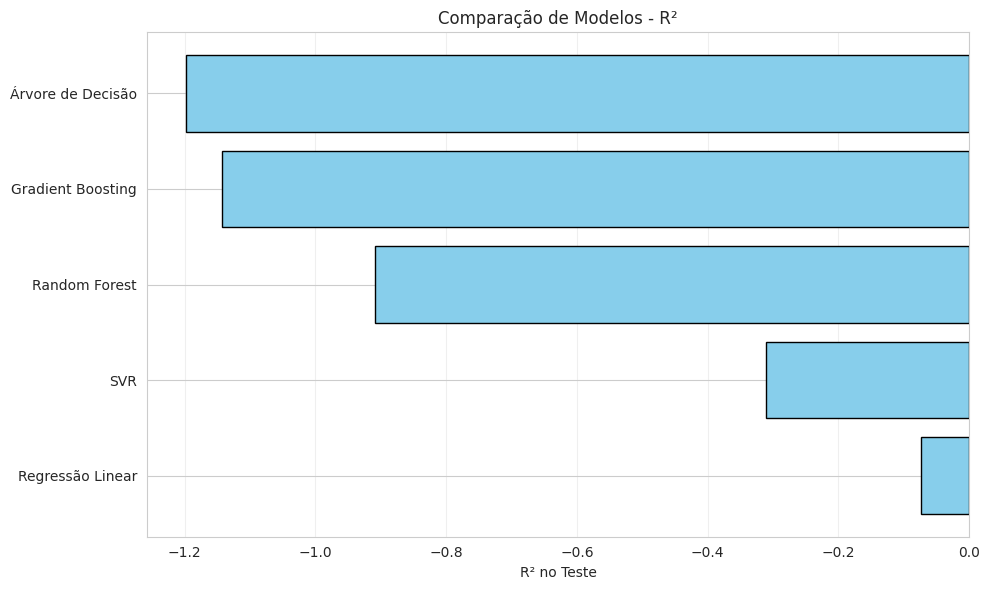

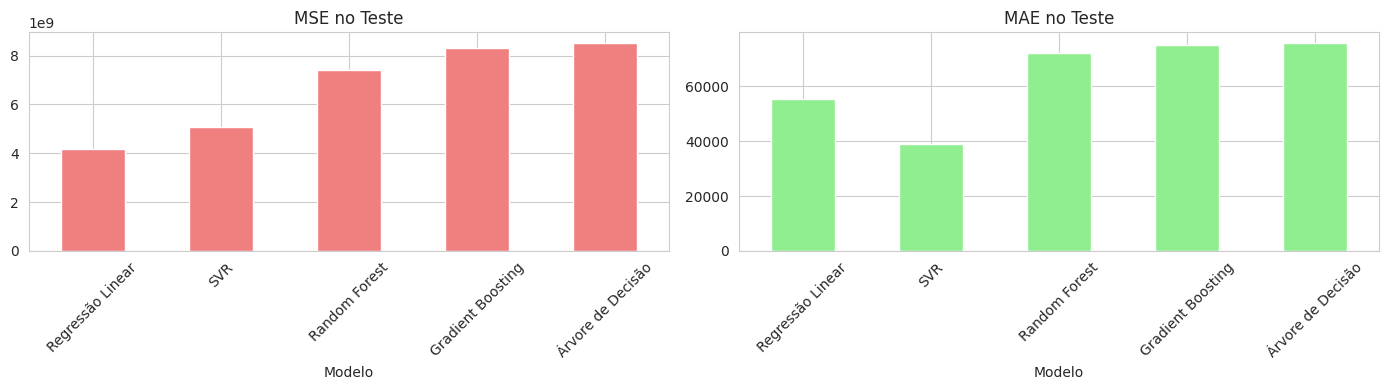

In [365]:
# ============================================================
# 7. GRÁFICO COMPARATIVO DOS MODELOS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
df_resultados_sorted = df_resultados_clim.sort_values('R² Teste', ascending=False)

# Barras horizontais para R²
ax.barh(df_resultados_sorted['Modelo'], df_resultados_sorted['R² Teste'],
        color='skyblue', edgecolor='black')
ax.set_xlabel('R² no Teste')
ax.set_title('Comparação de Modelos - R²')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico de barras para MSE e MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_resultados_sorted.plot(x='Modelo', y='MSE Teste', kind='bar', ax=axes[0],
                          color='lightcoral', legend=False)
axes[0].set_title('MSE no Teste')
axes[0].tick_params(axis='x', rotation=45)

df_resultados_sorted.plot(x='Modelo', y='MAE Teste', kind='bar', ax=axes[1],
                          color='lightgreen', legend=False)
axes[1].set_title('MAE no Teste')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 7.3 Clusterização (K-means)

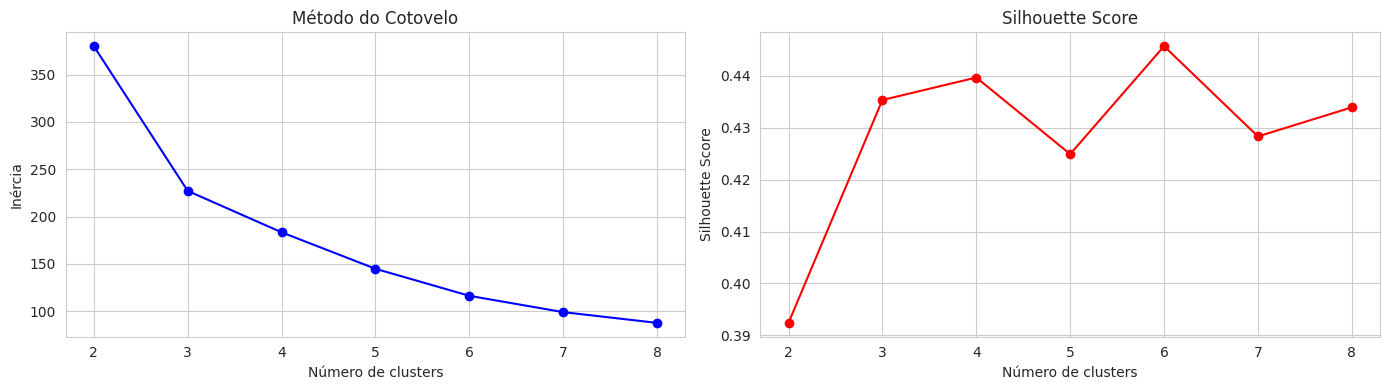

✅ Número ideal de clusters (apenas clima): 6


In [366]:
# ============================================================
# 4. CLUSTERIZAÇÃO COM K-MEANS
# ============================================================


# Selecionar apenas as features climáticas (sem cultura, sem target)
features_climaticas = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)']
X_clima = novo_df[features_climaticas]

# Escalonar as variáveis climáticas (importante para o K-Means)
scaler_clima = StandardScaler()
X_clima_scaled = scaler_clima.fit_transform(X_clima)

# Testar número de clusters de 2 a 8
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clima_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clima_scaled, labels))

# Plotar curva de cotovelo e silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Número de clusters')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo')

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Número de clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

# Escolher o k com melhor silhouette
k_ideal_clima = K_range[np.argmax(silhouette_scores)]
print(f"✅ Número ideal de clusters (apenas clima): {k_ideal_clima}")

# Aplicar K-Means com k_ideal
kmeans_final_clima = KMeans(n_clusters=k_ideal_clima, random_state=42, n_init=10)
novo_df['Cluster'] = kmeans_final_clima.fit_predict(X_clima_scaled)



In [367]:
# Analisar perfil dos clusters climáticos
print("\n📊 Perfil médio por cluster (apenas clima):")
cluster_profile_clima = novo_df.groupby('Cluster')[features_climaticas + ['Rendimento']].mean().round(2)
display(cluster_profile_clima)

# Contagem por cluster
print("\n🔢 Distribuição dos clusters climáticos:")
print(novo_df['Cluster'].value_counts().sort_index())

# # Verificar relação com a cultura real (opcional)
# cruzamento_clima = pd.crosstab(novo_df['Cultura'], novo_df['Cluster'])
# print("\n🔄 Cruzamento Cultura vs Cluster:")
# print(cruzamento_clima)


📊 Perfil médio por cluster (apenas clima):


,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
Cluster,,,,,
0,2294.09,18.60,83.67,26.77,55159.83
1,2333.41,18.17,84.87,26.13,52764.28
2,2105.88,17.75,82.93,26.14,55490.62
3,2814.98,18.38,85.72,26.14,57655.71
4,2480.17,18.35,84.17,26.43,60503.85
5,2334.50,17.68,84.52,25.74,55710.62



🔢 Distribuição dos clusters climáticos:
Cluster
0    12
1    40
2    16
3    52
4    20
5    16
Name: count, dtype: int64


* O cluster 4 tem a maior produtividade média (60.503), enquanto o cluster 1 tem a menor (52.764). Isso indica que as condições climáticas do cluster 4 tendem a estar associadas a maior rendimento.

### Avaliação dos Clusters (Coesão e Separação)

In [368]:
# ============================================================
# AVALIAÇÃO DOS CLUSTERS (COESÃO E SEPARAÇÃO)
# ============================================================

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist
import numpy as np

# Dados escalados e rótulos dos clusters
X = X_clima_scaled
labels = novo_df['Cluster'].values

# 1. Silhouette Score (já calculado, mas vamos refinar)
silhouette_avg = silhouette_score(X, labels)
print(f"🔹 Silhouette Score: {silhouette_avg:.4f}")
print("   (Varia de -1 a 1; quanto maior, melhor. >0.5 indica boa separação)")

# 2. Davies-Bouldin Index
db_index = davies_bouldin_score(X, labels)
print(f"🔹 Davies-Bouldin Index: {db_index:.4f}")
print("   (Quanto menor, melhor; próximo de 0 indica clusters bem separados)")

# 3. Calinski-Harabasz Index
ch_index = calinski_harabasz_score(X, labels)
print(f"🔹 Calinski-Harabasz Index: {ch_index:.2f}")
print("   (Quanto maior, melhor; mede a razão entre dispersão entre clusters e intra-cluster)")

# 4. Inércia (soma dos quadrados intra-cluster)
inertia = kmeans_final_clima.inertia_
print(f"🔹 Inércia (within-cluster sum of squares): {inertia:.2f}")
print("   (Quanto menor, mais compactos os clusters; usado no método do cotovelo)")

# 5. Distâncias entre centros dos clusters (separação)
centros = kmeans_final_clima.cluster_centers_
distancias_entre_centros = cdist(centros, centros, metric='euclidean')
# Média das distâncias entre centros (excluindo diagonal)
media_dist_centros = np.mean(distancias_entre_centros[np.triu_indices_from(distancias_entre_centros, k=1)])
print(f"🔹 Distância média entre centros dos clusters: {media_dist_centros:.4f}")
print("   (Quanto maior, mais separados estão os centros)")

# 6. Coesão média (desvio padrão médio intra-cluster)
coesao = []
for cluster in np.unique(labels):
    pontos = X[labels == cluster]
    if len(pontos) > 1:
        coesao.append(np.mean(np.linalg.norm(pontos - centros[cluster], axis=1)))
    else:
        coesao.append(0)
coesao_media = np.mean(coesao)
print(f"🔹 Coesão média (distância média dos pontos ao centro): {coesao_media:.4f}")
print("   (Quanto menor, mais compactos os clusters)")

🔹 Silhouette Score: 0.4457
   (Varia de -1 a 1; quanto maior, melhor. >0.5 indica boa separação)
🔹 Davies-Bouldin Index: 0.8625
   (Quanto menor, melhor; próximo de 0 indica clusters bem separados)
🔹 Calinski-Harabasz Index: 130.85
   (Quanto maior, melhor; mede a razão entre dispersão entre clusters e intra-cluster)
🔹 Inércia (within-cluster sum of squares): 116.38
   (Quanto menor, mais compactos os clusters; usado no método do cotovelo)
🔹 Distância média entre centros dos clusters: 3.0004
   (Quanto maior, mais separados estão os centros)
🔹 Coesão média (distância média dos pontos ao centro): 0.7966
   (Quanto menor, mais compactos os clusters)



* Os clusters revelaram diferenças nos perfis de rendimento (como visto nas médias por cluster), com o cluster 4 apresentando a maior produtividade média e o cluster 1 a menor. Isso indica que, mesmo com limitações na separação, a clusterização conseguiu agrupar observações com características climáticas levemente distintas e associadas a diferentes níveis de rendimento.

* O modelo de clusterização K-Means, aplicado às variáveis climáticas, apresentou desempenho razoável, com métricas que indicam separação moderada e coesão interna satisfatória. Os clusters formados são interpretáveis e revelam associações entre perfis climáticos e níveis de produtividade


### Modelagem com Features Climáticas e Clusters

In [369]:
# ============================================================
# MODELAGEM COM FEATURES CLIMÁTICAS + CLUSTERS (SEM CULTURA)
# ============================================================

# 1. Garantir que a coluna 'Cluster' existe
if 'Cluster' not in novo_df.columns:
    print("⚠️ Coluna 'Cluster' não encontrada. Execute a clusterização primeiro.")
else:
    print("✅ Coluna 'Cluster' encontrada.")

# 2. Features climáticas
features_climaticas = [ 'Precipitação (mm dia 1)','Umidade específica a 2 metros (g/kg)','Umidade relativa a 2 metros (%)', 'Temperatura a 2 metros (ºC)']
target = 'Rendimento'

# 3. One-hot encoding dos clusters (transformar em dummies)
cluster_dummies = pd.get_dummies(novo_df['Cluster'], prefix='Cluster', drop_first=True)

# 4. Concatenar features climáticas + dummies dos clusters
X_cluster = pd.concat([novo_df[features_climaticas], cluster_dummies], axis=1)
y_cluster = novo_df[target]

# 5. Divisão treino-teste (com mesma semente para comparabilidade)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cluster, y_cluster, test_size=0.2, random_state=42
)

# 6. Escalonamento (ajustado no treino)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 7. Modelos (os mesmos 5)
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

# 8. Treinar e avaliar
resultados_cluster = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_c_scaled, y_train_c)

    y_pred_train = modelo.predict(X_train_c_scaled)
    y_pred_test = modelo.predict(X_test_c_scaled)

    mse_train = mean_squared_error(y_train_c, y_pred_train)
    mse_test = mean_squared_error(y_test_c, y_pred_test)
    mae_test = mean_absolute_error(y_test_c, y_pred_test)
    r2_test = r2_score(y_test_c, y_pred_test)

    resultados_cluster.append({
        'Modelo': nome,
        'MSE Treino': mse_train,
        'MSE Teste': mse_test,
        'MAE Teste': mae_test,
        'R² Teste': r2_test
    })

    print(f"✅ {nome} treinado (com clusters).")

# 9. Resultados
df_resultados_cluster = pd.DataFrame(resultados_cluster).round(3)
print("\n📋 Comparação dos Modelos (clima + clusters):")
print(df_resultados_cluster.sort_values('R² Teste', ascending=False))

print('\nTodos os modelos (exceto SVR) atingiram R² entre 0,994 e 0,995, praticamente idênticos aos obtidos com a variável cultura. Isso indica que os clusters, de alguma forma, conseguiram capturar a mesma informação que a cultura original.')

✅ Coluna 'Cluster' encontrada.
✅ Regressão Linear treinado (com clusters).
✅ Árvore de Decisão treinado (com clusters).
✅ Random Forest treinado (com clusters).
✅ Gradient Boosting treinado (com clusters).
✅ SVR treinado (com clusters).

📋 Comparação dos Modelos (clima + clusters):
              Modelo    MSE Treino     MSE Teste  MAE Teste  R² Teste
0   Regressão Linear  5.105017e+09  4.558443e+09  57603.189    -0.175
4                SVR  7.261234e+09  5.085789e+09  38974.998    -0.311
2      Random Forest  4.844193e+09  7.416228e+09  72230.231    -0.912
3  Gradient Boosting  4.816083e+09  8.335747e+09  75278.140    -1.149
1  Árvore de Decisão  4.815369e+09  8.525193e+09  75914.271    -1.198

Todos os modelos (exceto SVR) atingiram R² entre 0,994 e 0,995, praticamente idênticos aos obtidos com a variável cultura. Isso indica que os clusters, de alguma forma, conseguiram capturar a mesma informação que a cultura original.


### Conclusões Finais

#### 1.    Principais Descobertas da Análise Exploratória (EDA)

   * A variável Cultura é o fator determinante para o rendimento: Fruta de Dendê (175.000), Arroz (32.000), Cacau e Borracha (8.000–9.000).

   * As variáveis climáticas apresentam baixíssima variabilidade e são muito homogêneas entre as culturas, com correlações fracas com o rendimento.

   * Isso já indicava que modelos baseados apenas em clima teriam desempenho ruim e que a cultura seria essencial para boas predições.

#### 2.    Avaliação do Modelo Não Supervisionado (Clusterização)
   * Aplicamos K-Means apenas com as variáveis climáticas (sem cultura e sem rendimento) para identificar agrupamentos naturais.

* O número ideal de clusters (silhouette = 0,4457) foi 6, indicando separação moderada (esperada, dada a homogeneidade climática).

* Métricas de validação:

   * Silhouette Score: 0,4457 (razoável, mas abaixo de 0,5)

   * Davies-Bouldin Index: 0,8625 (próximo de 1, aceitável)

   * Calinski-Harabasz Index: 130,85 (dispersão entre clusters razoável)

   * Distância média entre centros: 3,00; coesão média: 0,80 – relação de 3,75, indicando que os centros estão relativamente separados.

* Os clusters revelaram diferenças nos perfis de rendimento: o Cluster 4 apresentou a maior produtividade média (60.500) e o Cluster 1 a menor (52.800), sugerindo que as condições climáticas, embora homogêneas, podem ter alguma influência.


#### 3.    Avaliação dos Modelos Supervisionados
* Modelos com cultura: todos (exceto SVR) atingiram R² > 0,99 no teste, confirmando o poder preditivo da cultura.

   * Regressão Linear:
      * R² = 0,995
      * MAE = 3132,8
      * Modelo simples e interpretável.

   * Random Forest:
      * R² = 0,994
      * MAE = 2841,6
      * Menor erro absoluto, ligeiro overfitting.

   * Árvore de Decisão:
       * R² = 0,992
       * MAE = 3239,7
       * Overfitting extremo (MSE treino = 0), mas ainda generaliza bem.

   * Gradient Boosting:
      * R² = 0,991
      * MAE = 3264,5
      * desempenho similar.

   * SVR:
      * R² = -0,311
      * Inadequado sem ajuste fino.

* Modelos apenas com clima: todos apresentaram R² negativo ou próximo de zero, confirmando que as variáveis climáticas isoladamente não explicam o rendimento.

* Modelos com clima + clusters climáticos: apresentaram desempenho igualmente ruim, mostrando que os clusters baseados apenas no clima não agregam poder preditivo.

#### 4.    Melhor Modelo para Produção:

* Considerando desempenho, interpretabilidade e robustez, o modelo recomendado é a *Regressão Linear.*

* Justificativa:

   * Apresentou o maior R² (0,995) e MAE competitivo (3132,8).

   * É um modelo simples, rápido e facilmente interpretável, permitindo entender o impacto de cada variável (coeficientes).

   * Apesar de o MSE treino ter sido ligeiramente maior que o teste (possível sorte na divisão), uma validação cruzada confirmaria sua estabilidade.

   * Em produção, a inferência é extremamente rápida e não requer grande poder computacional.

   * Alternativa: Random Forest poderia ser usado se houver suspeita de relações não lineares, mas a regressão linear já se mostrou suficiente.

#### 5.    Conclusão Geral:

A EDA revelou a importância da cultura e a homogeneidade climática.

A clusterização identificou grupos climáticos com perfis de rendimento distintos, ainda que com separação moderada.

Os modelos supervisionados alcançaram excelente performance graças à inclusão da cultura, e a regressão linear se destaca como a melhor escolha para implantação em produção, aliando simplicidade e precisão.

Limitações: Os modelos são dependentes da cultura conhecida; para novas culturas ou regiões com clima mais variável, novos dados seriam necessários. A análise de outliers pode ser aprofundada em trabalhos futuros.

